# Gene Expression Peak-Trough analysis using Polar Plots

April 8, 2024

Analyze the chromatin at genes during peak and trough gene expression.

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from src.mnase_replication_timing_analysis import MNaseOriginAnalysis

# Compute replication profile for each gene

For each gene
1. Compute the raw replication profile
2. Compute its replication time (early/late)
3. Will need to normalize by the replicate's S phase
4. Compute the correlation with its gene expression


In [3]:
mnase_analysis = MNaseOriginAnalysis()

In [4]:
replicate = 1
chromosome = 10
mnase_analysis.load_mnase_data(replicate, chromosome)

In [5]:
mnase_analysis.compute_sliding_window_counts_all_times()
mnase_analysis.normalize_samples()

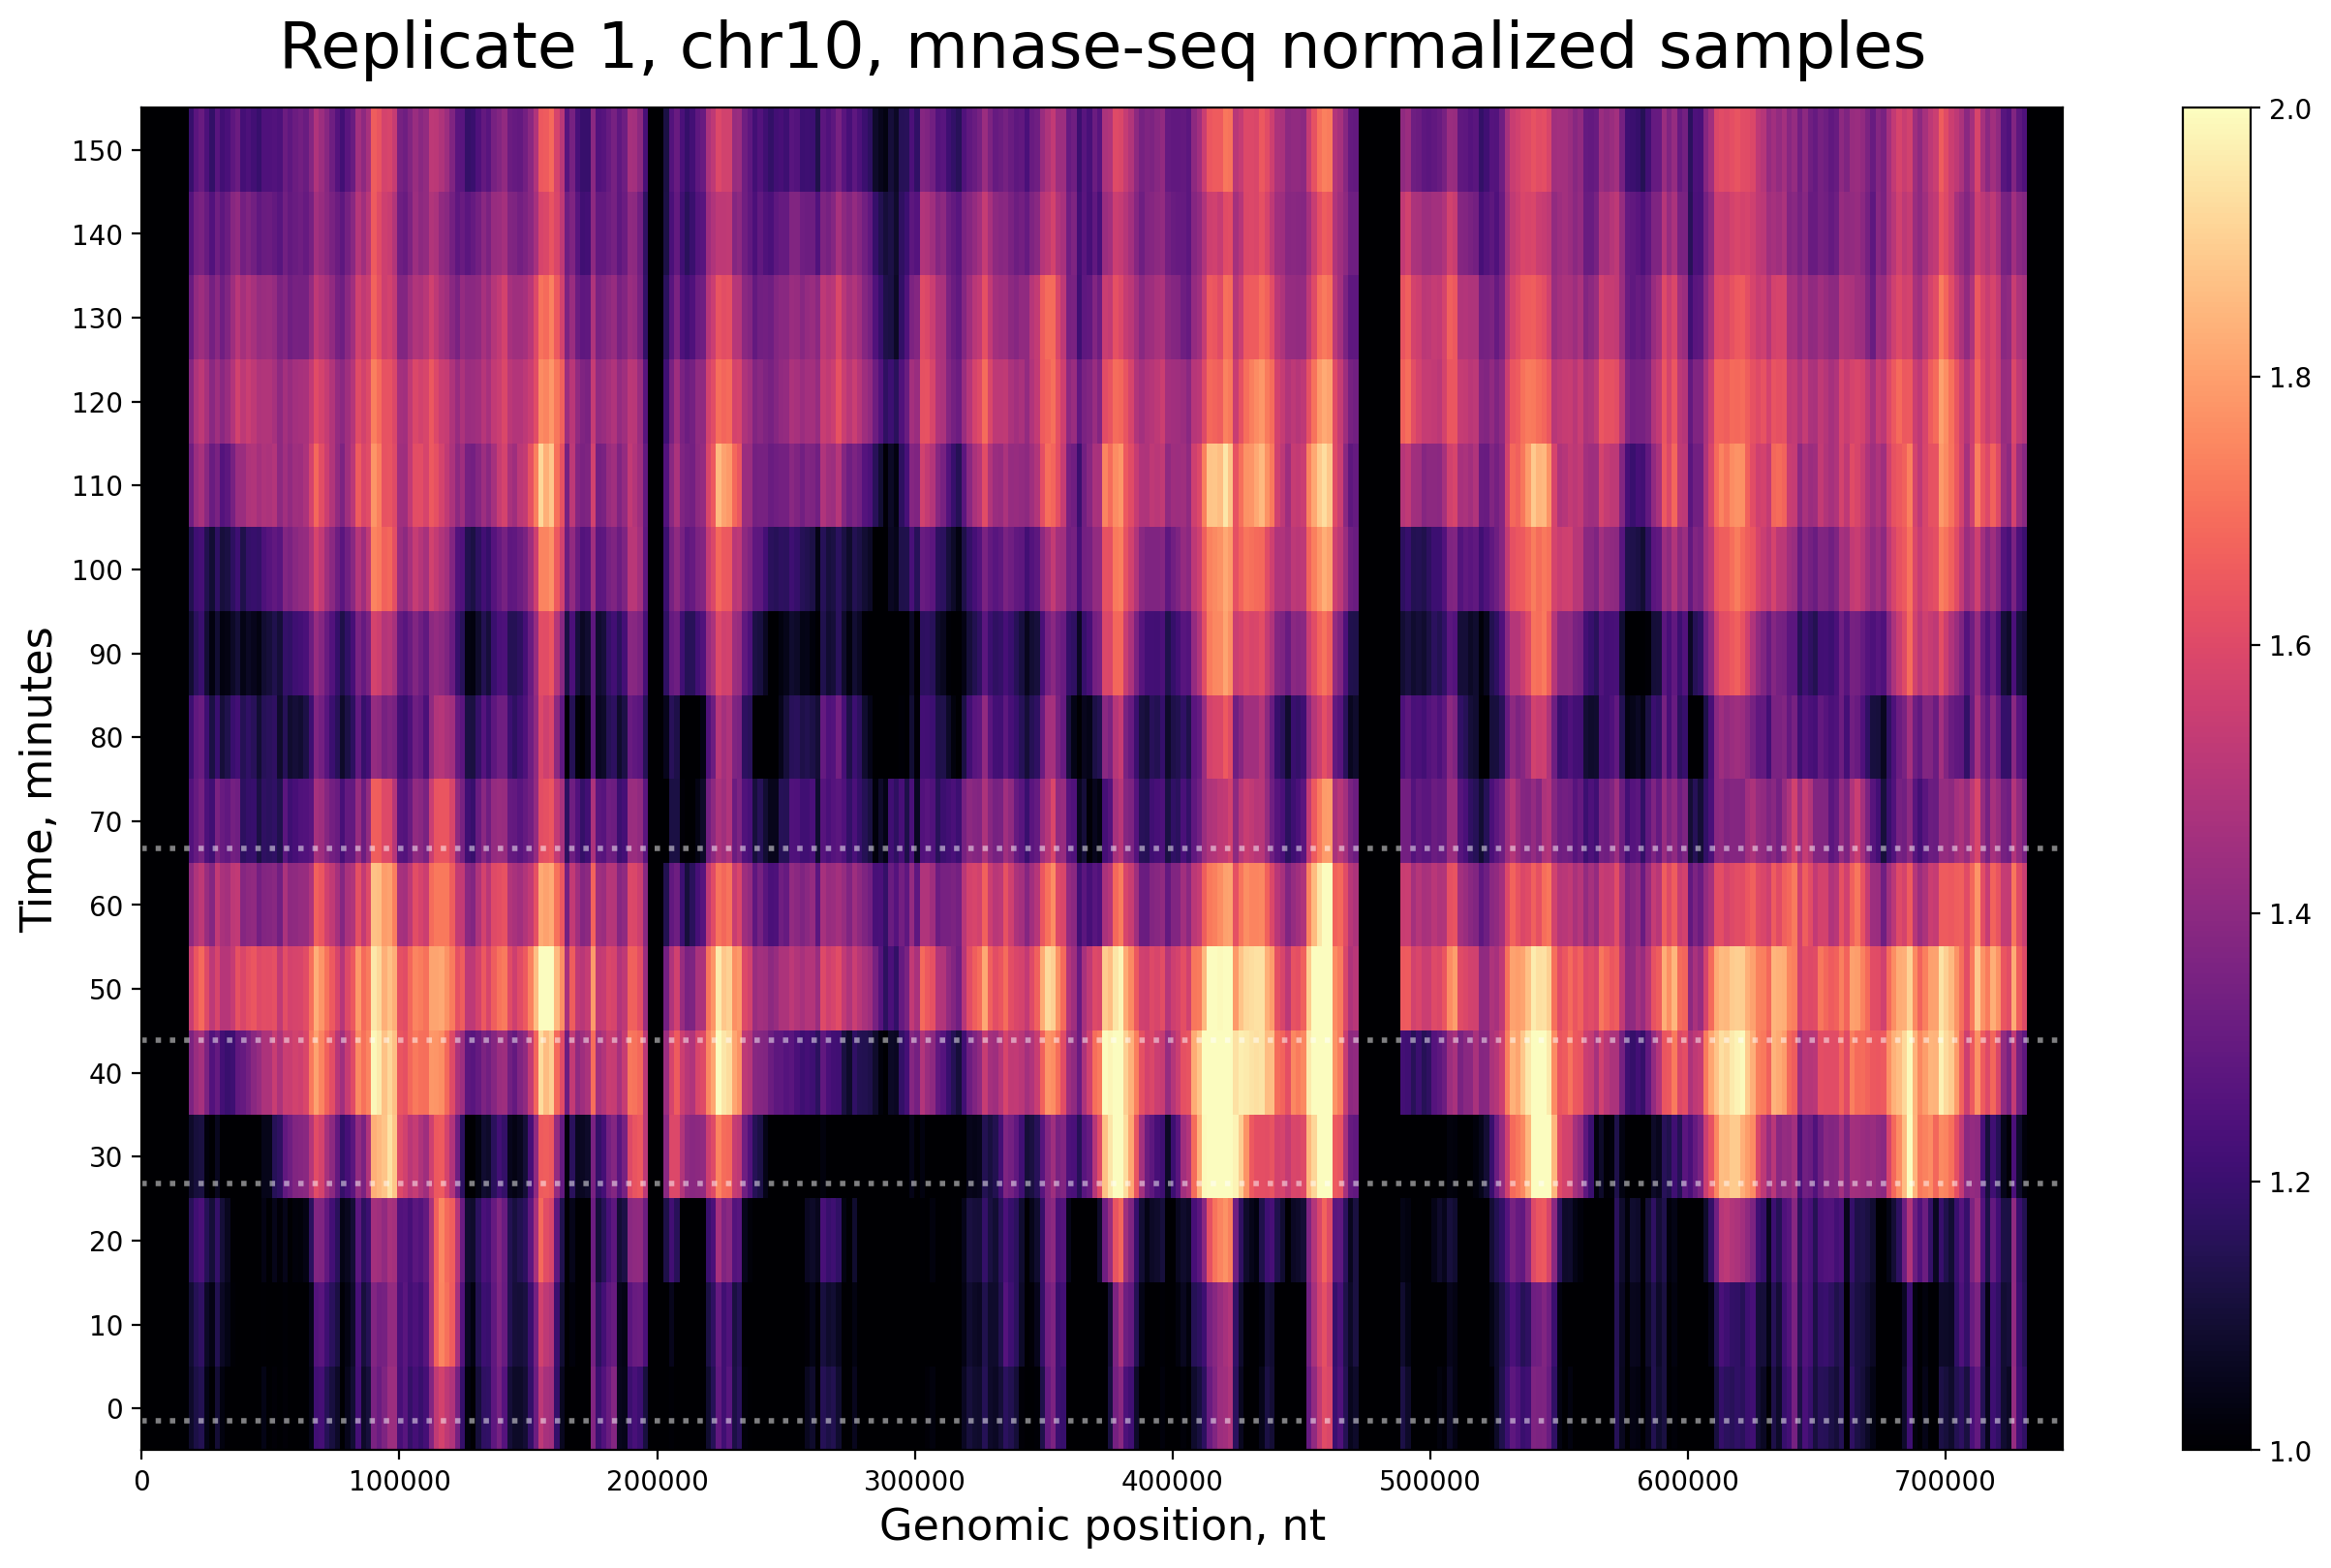

In [6]:
mnase_analysis.plot_heatmap(plot_norm_by_copy=True)

# Compute replication timing profile for both replicates

Compute the 10k bin curves for all genes, normalize the occupancy within the first cell cycle length, then compute the time in which the occupancy reaches a specified threshold (currently 75%) for each gene. The time in which this threshold is met is the replication timing.

Perform for both genes, compute the correlation and take the average.


In [141]:
mnase_analysis_rep1 = MNaseOriginAnalysis(replicate=1)
mnase_analysis_rep1.compute_bin_curves_and_expression_correlations()
mnase_analysis_rep1.compute_replication_timing()

1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 00:02:15.915


In [142]:
mnase_analysis_rep2 = MNaseOriginAnalysis(replicate=2)
mnase_analysis_rep2.compute_bin_curves_and_expression_correlations()
mnase_analysis_rep2.compute_replication_timing()

1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 00:02:22.560


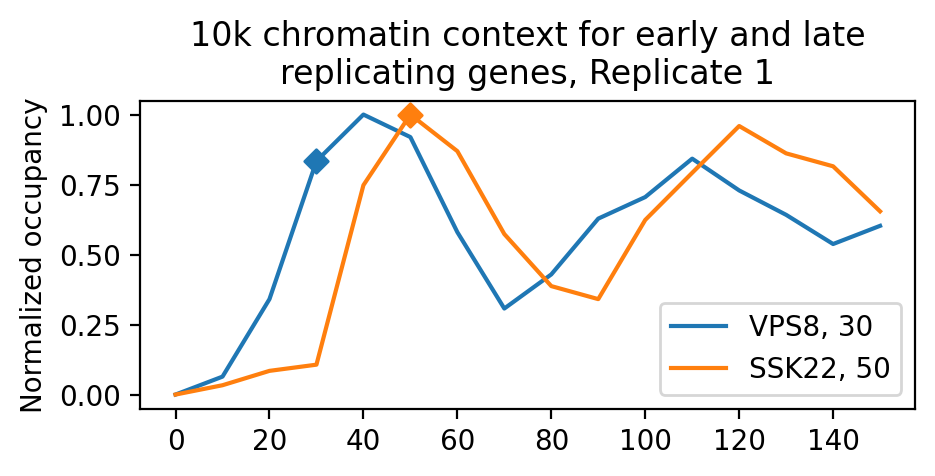

In [301]:
mnase_analysis_rep1.plot_normalized_bin_curves(['VPS8', 'SSK22'])

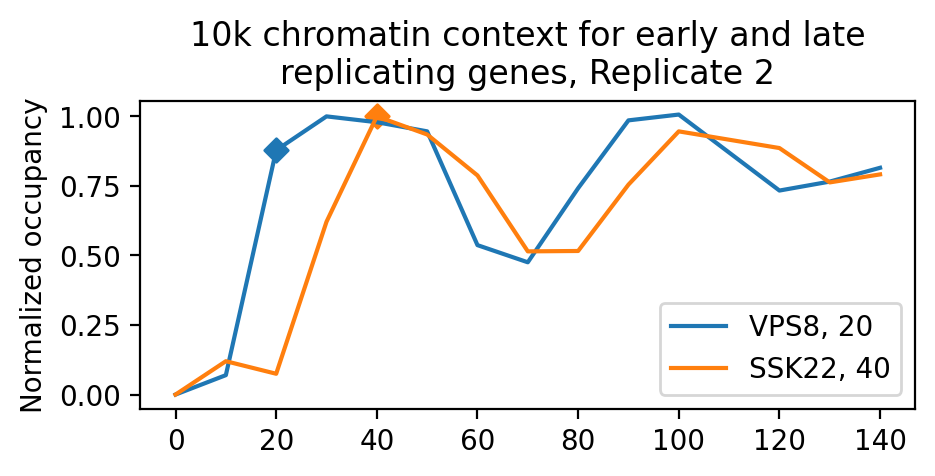

In [302]:
mnase_analysis_rep2.plot_normalized_bin_curves(['VPS8', 'SSK22'])

In [224]:
mnase_analysis_rep1.load_posteriors_for_timing()
mnase_analysis_rep2.load_posteriors_for_timing()

In [238]:
# We have where G1 should start (w/o recovery) and the length of the cell cycle
# so let's normalize based on translating to the that G1 start
# then divide by the cell cycle length

mnase_analysis_rep1.normalize_replication_timing_by_cell_cycle_parameters()
mnase_analysis_rep2.normalize_replication_timing_by_cell_cycle_parameters()

Text(0.5, 0.98, 'Distribution of replication timing')

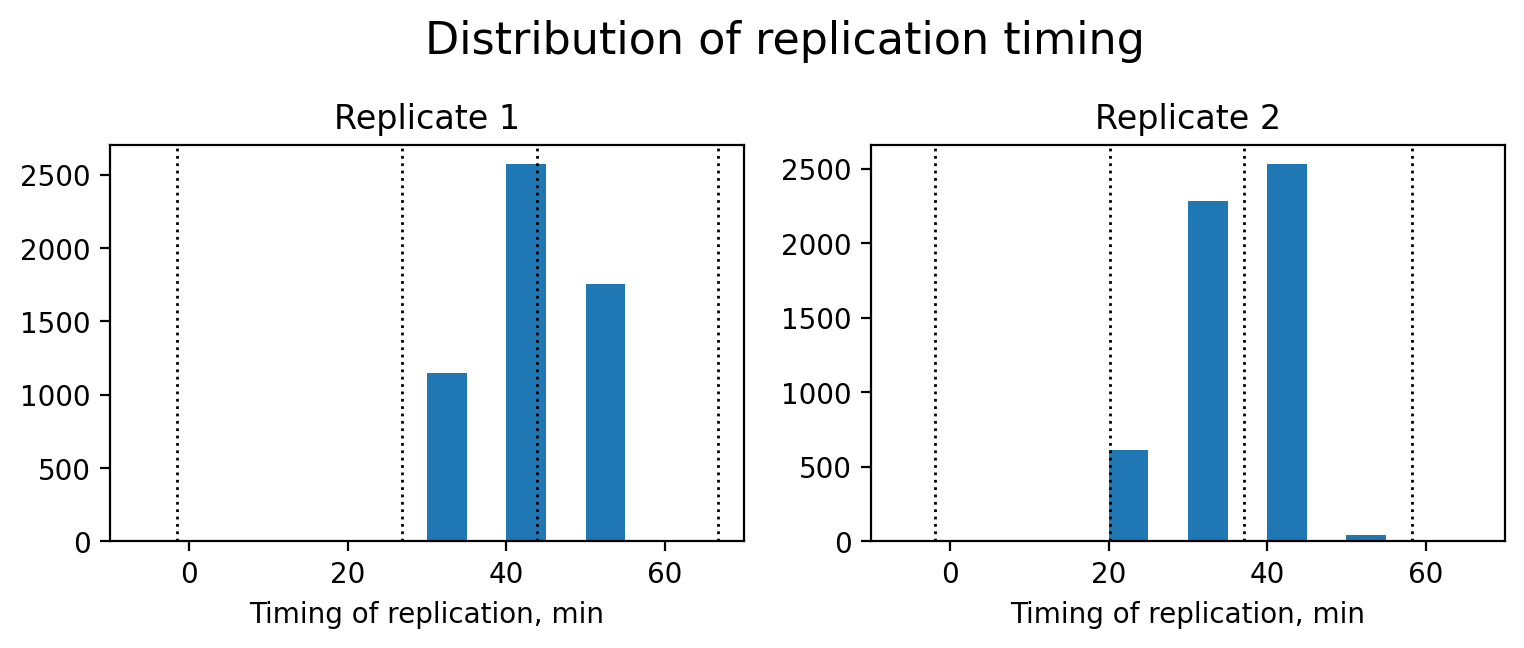

In [303]:
bins = np.arange(0, 70, 5)-5

plt.figure(figsize=(9, 3))
plt.subplots_adjust(top=0.77)

plt.subplot(1, 2, 1)
plt.hist(mnase_analysis_rep1.repl_timing_df, bins=bins)

def plot_lines(lines):
    for line in lines:
        plt.axvline(line, c='black', lw=1, ls='dotted')

plot_lines([
    mnase_analysis_rep1.g1_recovery_would_start_here,
    mnase_analysis_rep1.first_s_start,
    mnase_analysis_rep1.first_s_end,
    mnase_analysis_rep1.end_of_first_lambd,
])

plt.xlim(-10, 70)
plt.title("Replicate 1")
plt.xlabel("Timing of replication, min")

plt.subplot(1, 2, 2)
plt.hist(mnase_analysis_rep2.repl_timing_df, bins=bins)

plot_lines([
    mnase_analysis_rep2.g1_recovery_would_start_here,
    mnase_analysis_rep2.first_s_start,
    mnase_analysis_rep2.first_s_end,
    mnase_analysis_rep2.end_of_first_lambd,
])

plt.xlim(-10, 70)
plt.title("Replicate 2")
plt.xlabel("Timing of replication, min")

plt.suptitle("Distribution of replication timing", fontsize=16)

In [262]:
merged_replication_timing = pd.DataFrame(mnase_analysis_rep1.normalized_timing, columns=['repl_timing1']).join(
    pd.DataFrame(mnase_analysis_rep2.normalized_timing, columns=['repl_timing2']))
merged_replication_timing['mean'] = merged_replication_timing.mean(axis=1)

([], [])

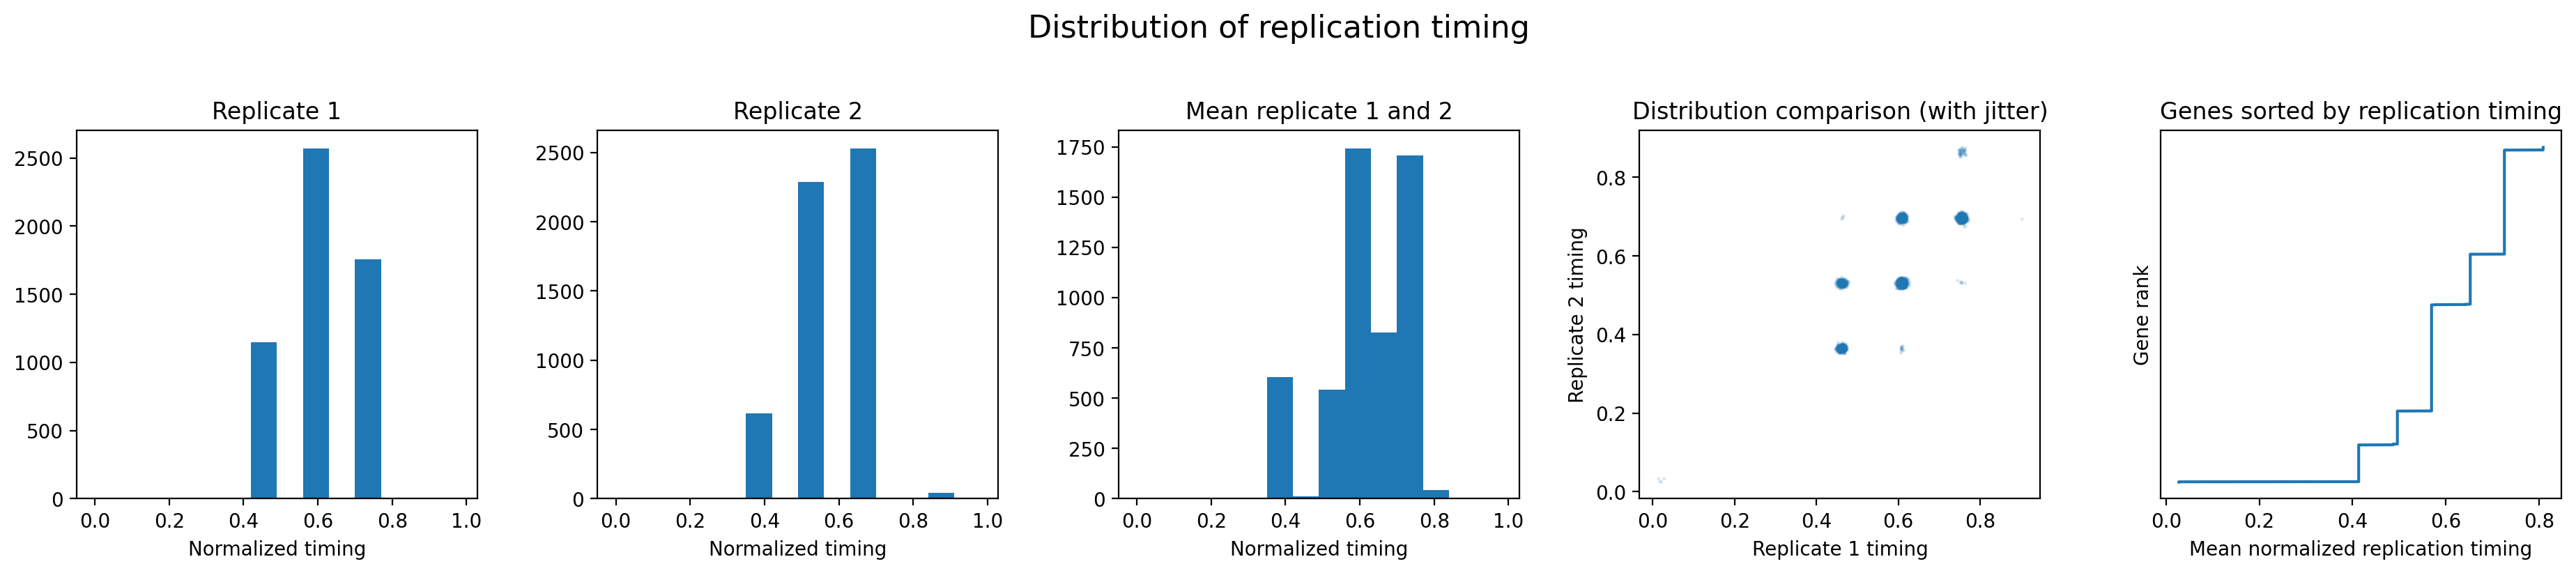

In [308]:

bins = np.arange(0, 1, 0.07)

plt.figure(figsize=(23, 4))
plt.subplots_adjust(top=0.77, wspace=0.3)

plt.subplot(1, 5, 1)
plt.hist(merged_replication_timing.repl_timing1, bins=bins)
plt.title("Replicate 1")
plt.xlabel("Normalized timing")

plt.subplot(1, 5, 2)
plt.hist(merged_replication_timing.repl_timing2, bins=bins)
plt.title("Replicate 2")
plt.xlabel("Normalized timing")

plt.subplot(1, 5, 3)
plt.hist(merged_replication_timing['mean'], bins=bins)
plt.title("Mean replicate 1 and 2")
plt.xlabel("Normalized timing")

plt.suptitle("Distribution of replication timing", fontsize=16)

plt.subplot(1, 5, 4)
from scipy.stats.distributions import norm

n = len(merged_replication_timing)
x_jitter = norm.rvs(loc=0, scale=0.005, size=n)
y_jitter = norm.rvs(loc=0, scale=0.005, size=n)

plt.scatter(merged_replication_timing.repl_timing1 + x_jitter, 
            merged_replication_timing.repl_timing2 + y_jitter,
           s=1, alpha=0.1)
plt.xlabel("Replicate 1 timing")
plt.ylabel("Replicate 2 timing")
plt.title("Distribution comparison (with jitter)")

plt.subplot(1, 5, 5)
x = np.arange(n)
plt.plot(merged_replication_timing.sort_values('mean')['mean'], x)
plt.title("Genes sorted by replication timing")
plt.xlabel("Mean normalized replication timing")
plt.ylabel("Gene rank")
plt.yticks([])

In [282]:
merged_replication_timing.to_csv('datasets/computed_mnase/replication_timing_10k.csv')

In [309]:
# Load the F images, currently we have them ready to plot in the promoter analysis
# but we will move them to its own class

from src.promoter_ptr_analysis import PromoterPTRAnalysis

chromatin_dir = 'output/deconvolve_combined_g_opt_2024_03_14/chromatin/'
promoter_analysis = PromoterPTRAnalysis(chromatin_dir)

In [310]:
promoter_analysis.load_f_files()

Shape of the loaded F: (227, 200)
1/5574 - 00:00:00.135
1001/5574 - 00:00:07.435
2001/5574 - 00:00:13.404
3001/5574 - 00:00:19.215
4001/5574 - 00:00:25.011
5001/5574 - 00:00:30.780


In [311]:
promoter_analysis.correct_f_images_by_strand()

In [334]:
strand_corrected_f_images = promoter_analysis.strand_corrected_f_images

In [357]:
# The f images are in a numpy array so keep track of the indices
gene_indices = promoter_analysis.geneset[['gene']].copy()
gene_indices['gene_index'] = np.arange(len(gene_indices))

# Replication timing is a subset, so let's subset the f images
gene_indices = gene_indices.loc[merged_replication_timing.index]
repl_timing = gene_indices.join(merged_replication_timing[['mean']])

sc_f_imgs_with_rep = strand_corrected_f_images[gene_indices.gene_index.values]

# Reset the gene index because we have now subsetted
repl_timing['gene_index'] = np.arange(len(repl_timing))

In [358]:
sc_f_imgs_with_rep.shape

(5482, 227, 8, 25)

In [568]:
# Now we have the indices and the replication timing, let's plot the 
# top 500 genes in aggregate and the lower 500 genes

repl_timing = repl_timing.sort_values('mean')

k = 500
top_500_early = repl_timing.iloc[0:k]
bottom_500_late = repl_timing.iloc[-k:]

In [570]:
top_500_early_imgs_aggregated = sc_f_imgs_with_rep[top_500_early.gene_index].mean(axis=0)
bottom_500_late_imgs_aggregated = sc_f_imgs_with_rep[bottom_500_late.gene_index].mean(axis=0)

In [571]:
# Let's plot the aggreagete plots through various segments of the cell cycle
# CG1:
config = load_yl_rg1_vst_config(1)

cg1_indices = config.get_Hpositions_for_phase('CG1')
dg1_indices = config.get_Hpositions_for_phase('DG1')
postg1_indices = config.get_Hpositions_for_phase('postG1')

def subset_the_indices(indices, size):
    subset_indices = np.linspace(0, len(indices)-1, size).astype(int)
    return indices[subset_indices]

n = 10
cg1_indices_subset = subset_the_indices(cg1_indices, n)
dg1_indices_subset = subset_the_indices(dg1_indices, n)
postg1_indices_subset = subset_the_indices(postg1_indices, n)

In [618]:
# Plot CG1 and DG1 and PostG1
# Compare top 500 and bottom 500 replication timing genes

def plot_phase_subset(aggregate_imgs1, aggregate_imgs2,
                      subset_indices, phase):
    phase_imgs1 = aggregate_imgs1[subset_indices]
    phase_imgs2 = aggregate_imgs2[subset_indices]
    n = len(phase_imgs1)

    fig, axs = plt.subplots(n, 3, figsize=(5, 5))
    plt.subplots_adjust(wspace=0.05)
    
    for i in range(n):
        img1 = phase_imgs1[i]
        img2 = phase_imgs2[i]
        
        ax_row = axs[i]
        
        ax = ax_row[0]
        ax.imshow(img1, origin='lower', cmap='magma_r', vmax=20, aspect='auto')
        ax.set_xticks([])
        ax.set_yticks([])
        if i == 0: ax.set_title(f"Early {k}")
        
        ax = ax_row[1]
        ax.imshow(img2, origin='lower', cmap='magma_r', vmax=20, aspect='auto')
        ax.set_xticks([])
        ax.set_yticks([])
        if i == 0: ax.set_title(f"Late {k}")
            
        ax = ax_row[2]
        im = ax.imshow(img1-img2, origin='lower', cmap='RdBu_r', vmax=2, vmin=-2,
                  aspect='auto')
        ax.set_xticks([])
        ax.set_yticks([])

        if i == 0: ax.set_title(f"Difference\nEarly-Late")

    plt.suptitle(phase)

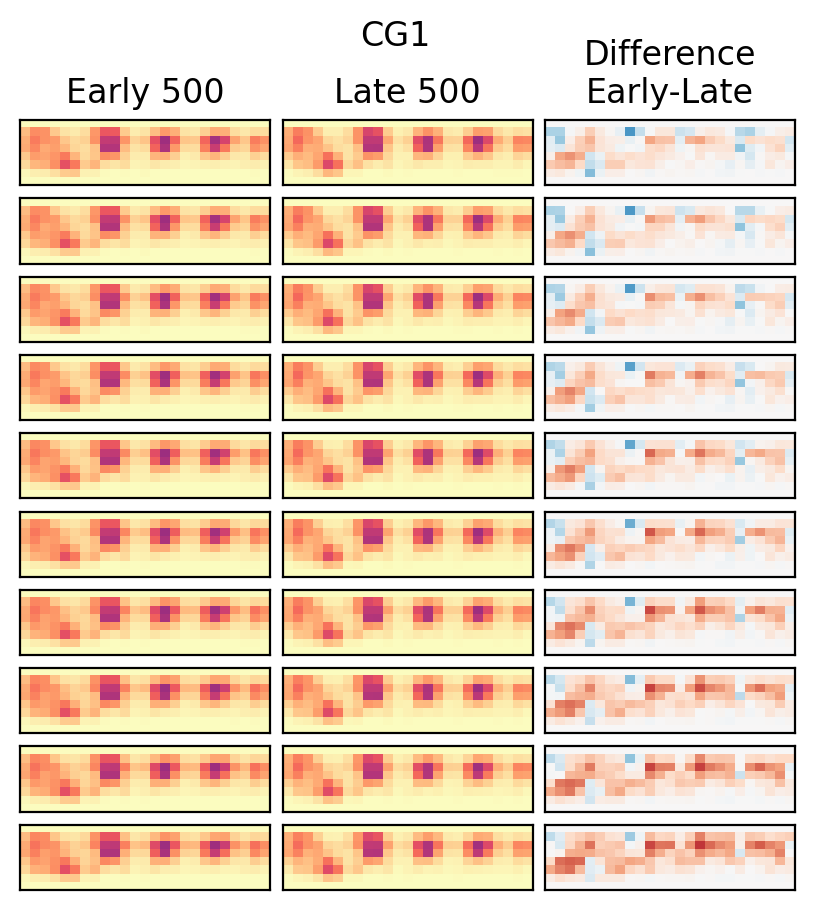

In [619]:
plot_phase_subset(top_500_early_imgs_aggregated, bottom_500_late_imgs_aggregated,
                  cg1_indices_subset, phase="CG1")


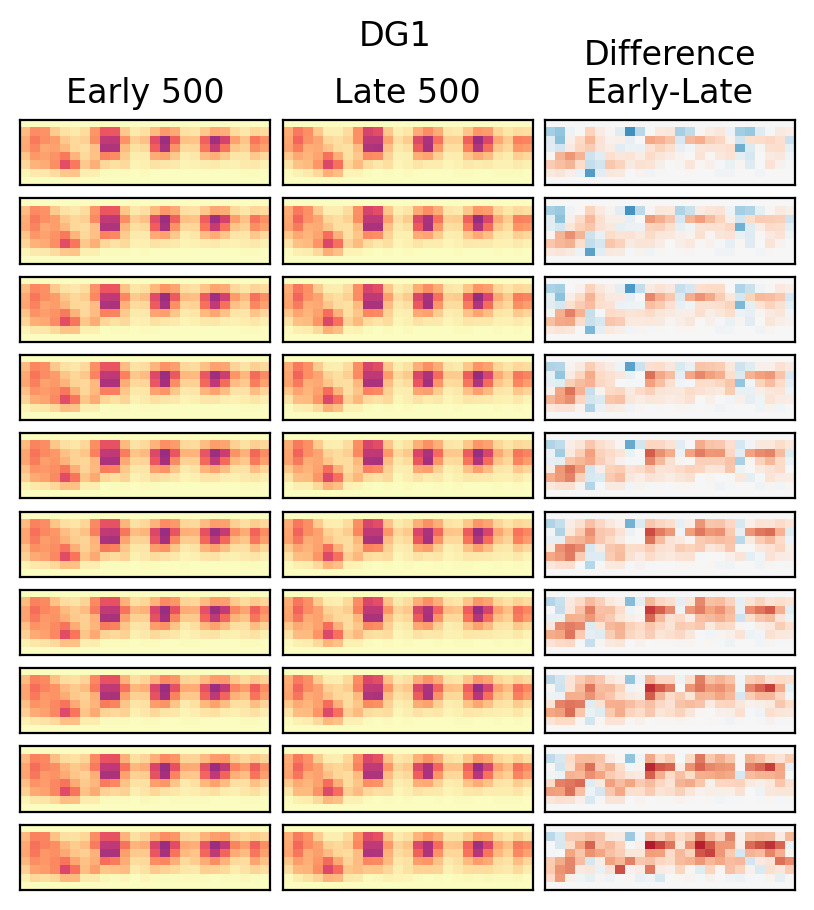

In [620]:
plot_phase_subset(top_500_early_imgs_aggregated, bottom_500_late_imgs_aggregated,
                  dg1_indices_subset, phase="DG1")


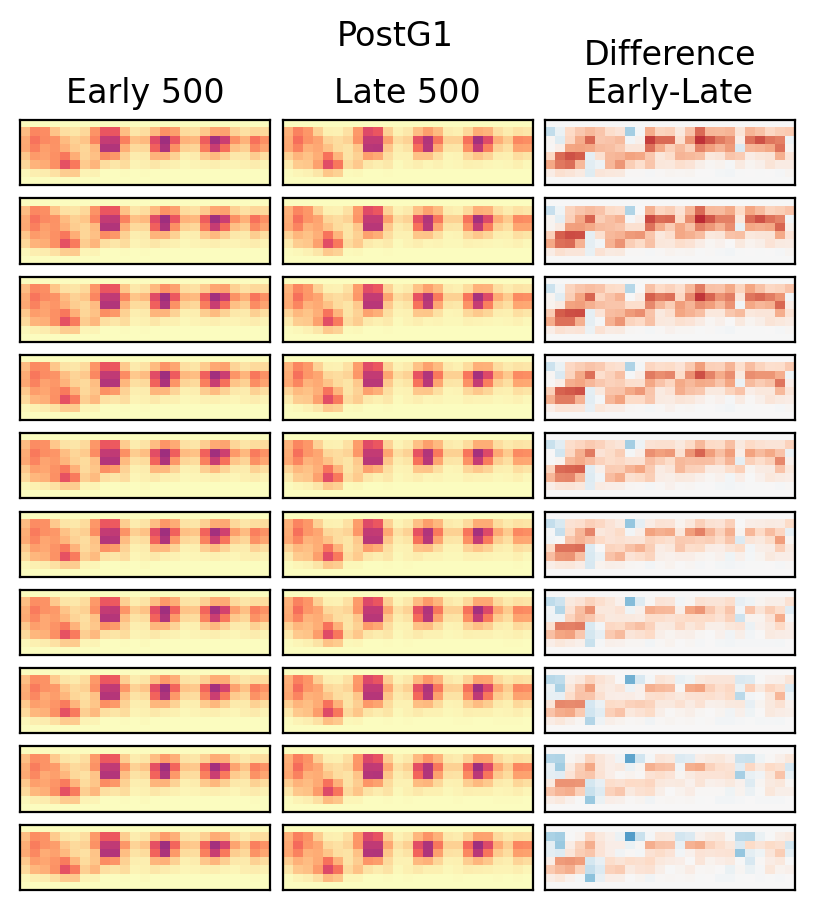

In [621]:
plot_phase_subset(top_500_early_imgs_aggregated, bottom_500_late_imgs_aggregated,
                  postg1_indices_subset, phase="PostG1")


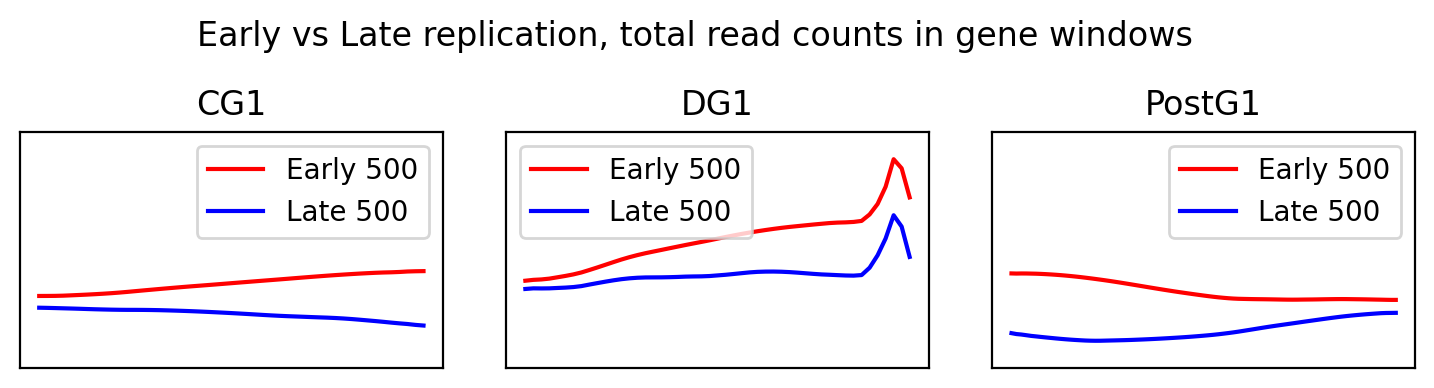

In [586]:

fig, axs = plt.subplots(1, 3, figsize=(9, 2))

indices = np.concatenate([cg1_indices, dg1_indices, postg1_indices])
all_top_values = top_500_imgs_aggregated[indices].sum(axis=1).sum(axis=1)
all_bottom_values = bottom_500_imgs_aggregated[indices].sum(axis=1).sum(axis=1)

all_values = np.concatenate([all_top_values, all_bottom_values])

ymin = all_values.min()
ymax = all_values.max()
ydelta = ymax-ymin
ylim = ymin-ydelta*0.15, ymax+ydelta*0.15

def plot_phase_sum(ax, indices, phase):
    ax.plot(top_500_early_imgs_aggregated[indices].sum(axis=1).sum(axis=1), 
            label=f"Early {k}", c='red')
    ax.plot(bottom_500_late_imgs_aggregated[indices].sum(axis=1).sum(axis=1),
            label=f"Late {k}",
           c='blue')
    ax.set_title(phase)
    ax.legend()
    ax.set_ylim((*ylim))
    ax.set_xticks([])
    ax.set_yticks([])
    
plot_phase_sum(axs[0], cg1_indices, 'CG1')
plot_phase_sum(axs[1], dg1_indices, 'DG1')
plot_phase_sum(axs[2], postg1_indices, 'PostG1')
plt.suptitle("Early vs Late replication, total read counts in gene windows")
plt.subplots_adjust(top=0.7, wspace=0.15)

In [676]:
# Investigate alpha parameter with regards to S-phase 
# Is alpha parameter properly tuned to handle the location of S-phase? Yes
# Is it tuned to capture the separation between G2M and G1? Possibly no, according
# the MNase 10k window occupancy


In [699]:
# Deconvolve CLN1 with alpha=0 and alpha=28

from src.config import load_yl_replicate1_rg1_alpha_vst_config
from src.dynamic_config_alpha import create_dynamic_alpha_config
from src.model import Model


In [729]:
# I believe my hypothesis may be worth pursuing:

# That the alpha values are a little too high.
# Result: Deconvolve the bin curve for CLN1, the expectation is G1 should be flattish until
# the start of S-phase

# with an alpha = 28, the G1 curve starts high and dips, indicating that
# the start of G1 should actually be allocated to the end of G2M
# about 20 minutes of the curve should be adjusted from this observation
# we will need to see how this affects the daughter-specific genes as well....

# The hope is that this will allow us to come up with a very high resolution
# replication timing profile, if this is done properly.
# Let's try some specifically early and late replicating genes
# and DSE1...

# An early and late replicating gene
from src.sgd import get_orfname
orf_early = get_orfname('VPS8')
orf_late = get_orfname('SSK22')

early_bin_curve = mnase_analysis_rep1.normalized_bin_curves.loc[orf_early]
late_bin_curve = mnase_analysis_rep1.normalized_bin_curves.loc[orf_late]

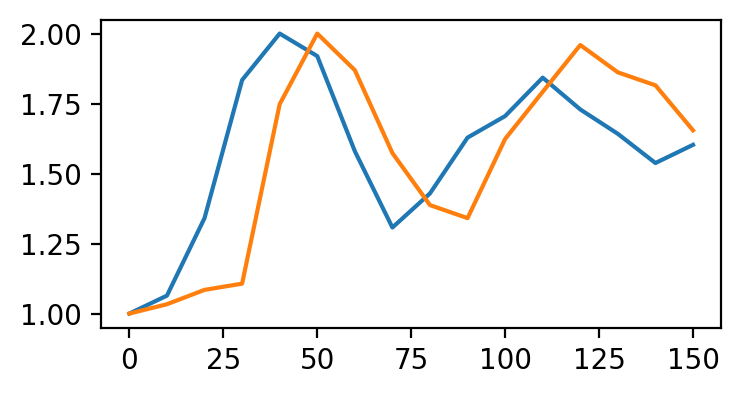

In [735]:
plt.figure(figsize=(4, 2))
plt.plot(early_bin_curve+1.)
plt.plot(late_bin_curve+1.)

In [748]:
def compare_early_late_deconv_bin_curves(alpha):
    dynamic_config = create_dynamic_alpha_config(alpha, 1)

    gene_name = "CLN1"
    model = Model(dynamic_config, gene_name)

    model.g = early_bin_curve+1.
    model.g1 = early_bin_curve+1.
    model.deconvolve_find_optimal_gamma()
    _ = model_alpha28.plot_deconvolved_gene()
    plt.suptitle(f"Early replicating 10k bin, $\\alpha$={alpha}\nsn={model.sn:.2f}, rn={model.rn:.2f}"
        f", gamma={model.gamma:.3f}, Replicate 1", fontsize=32)

    model.g = late_bin_curve+1.
    model.g1 = late_bin_curve+1.
    model.deconvolve_find_optimal_gamma()

    _ = model.plot_deconvolved_gene()
    plt.suptitle(f"Late replicating 10k bin, $\\alpha$={alpha}\nsn={model.sn:.2f}, rn={model.rn:.2f}"
        f"\ngamma={model.gamma:.3f}, "
                 "Replicate 1", fontsize=32)

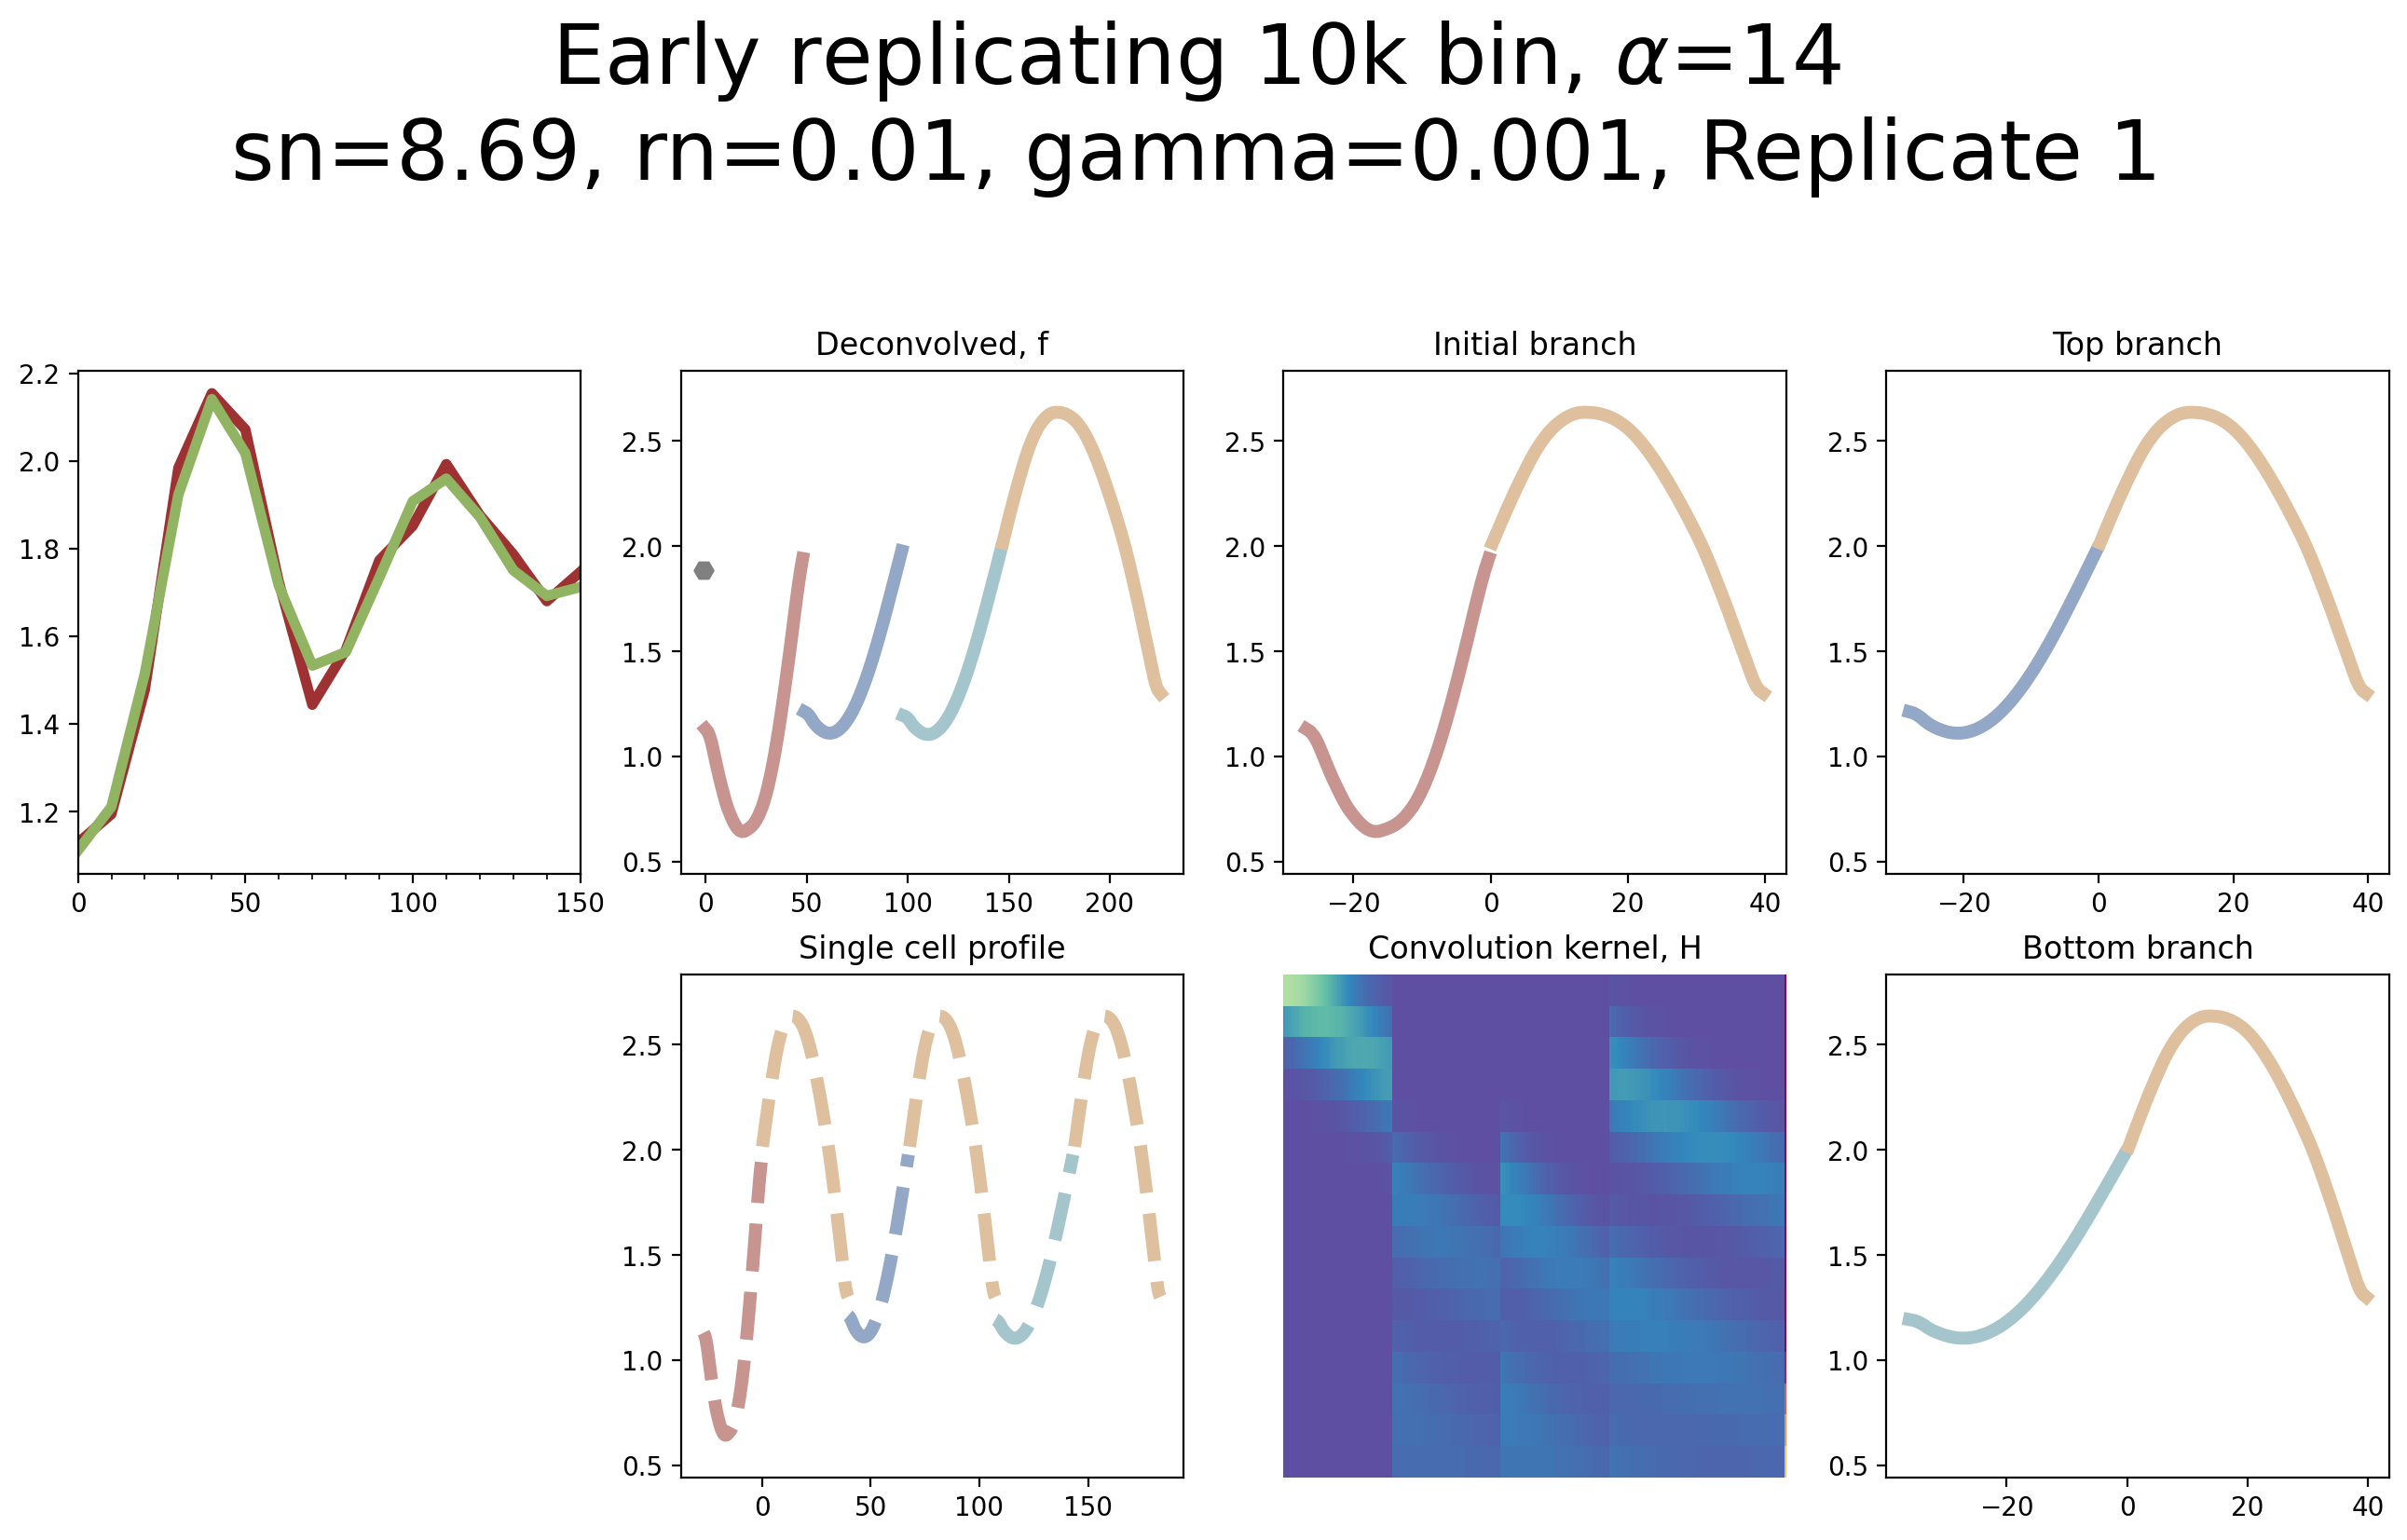

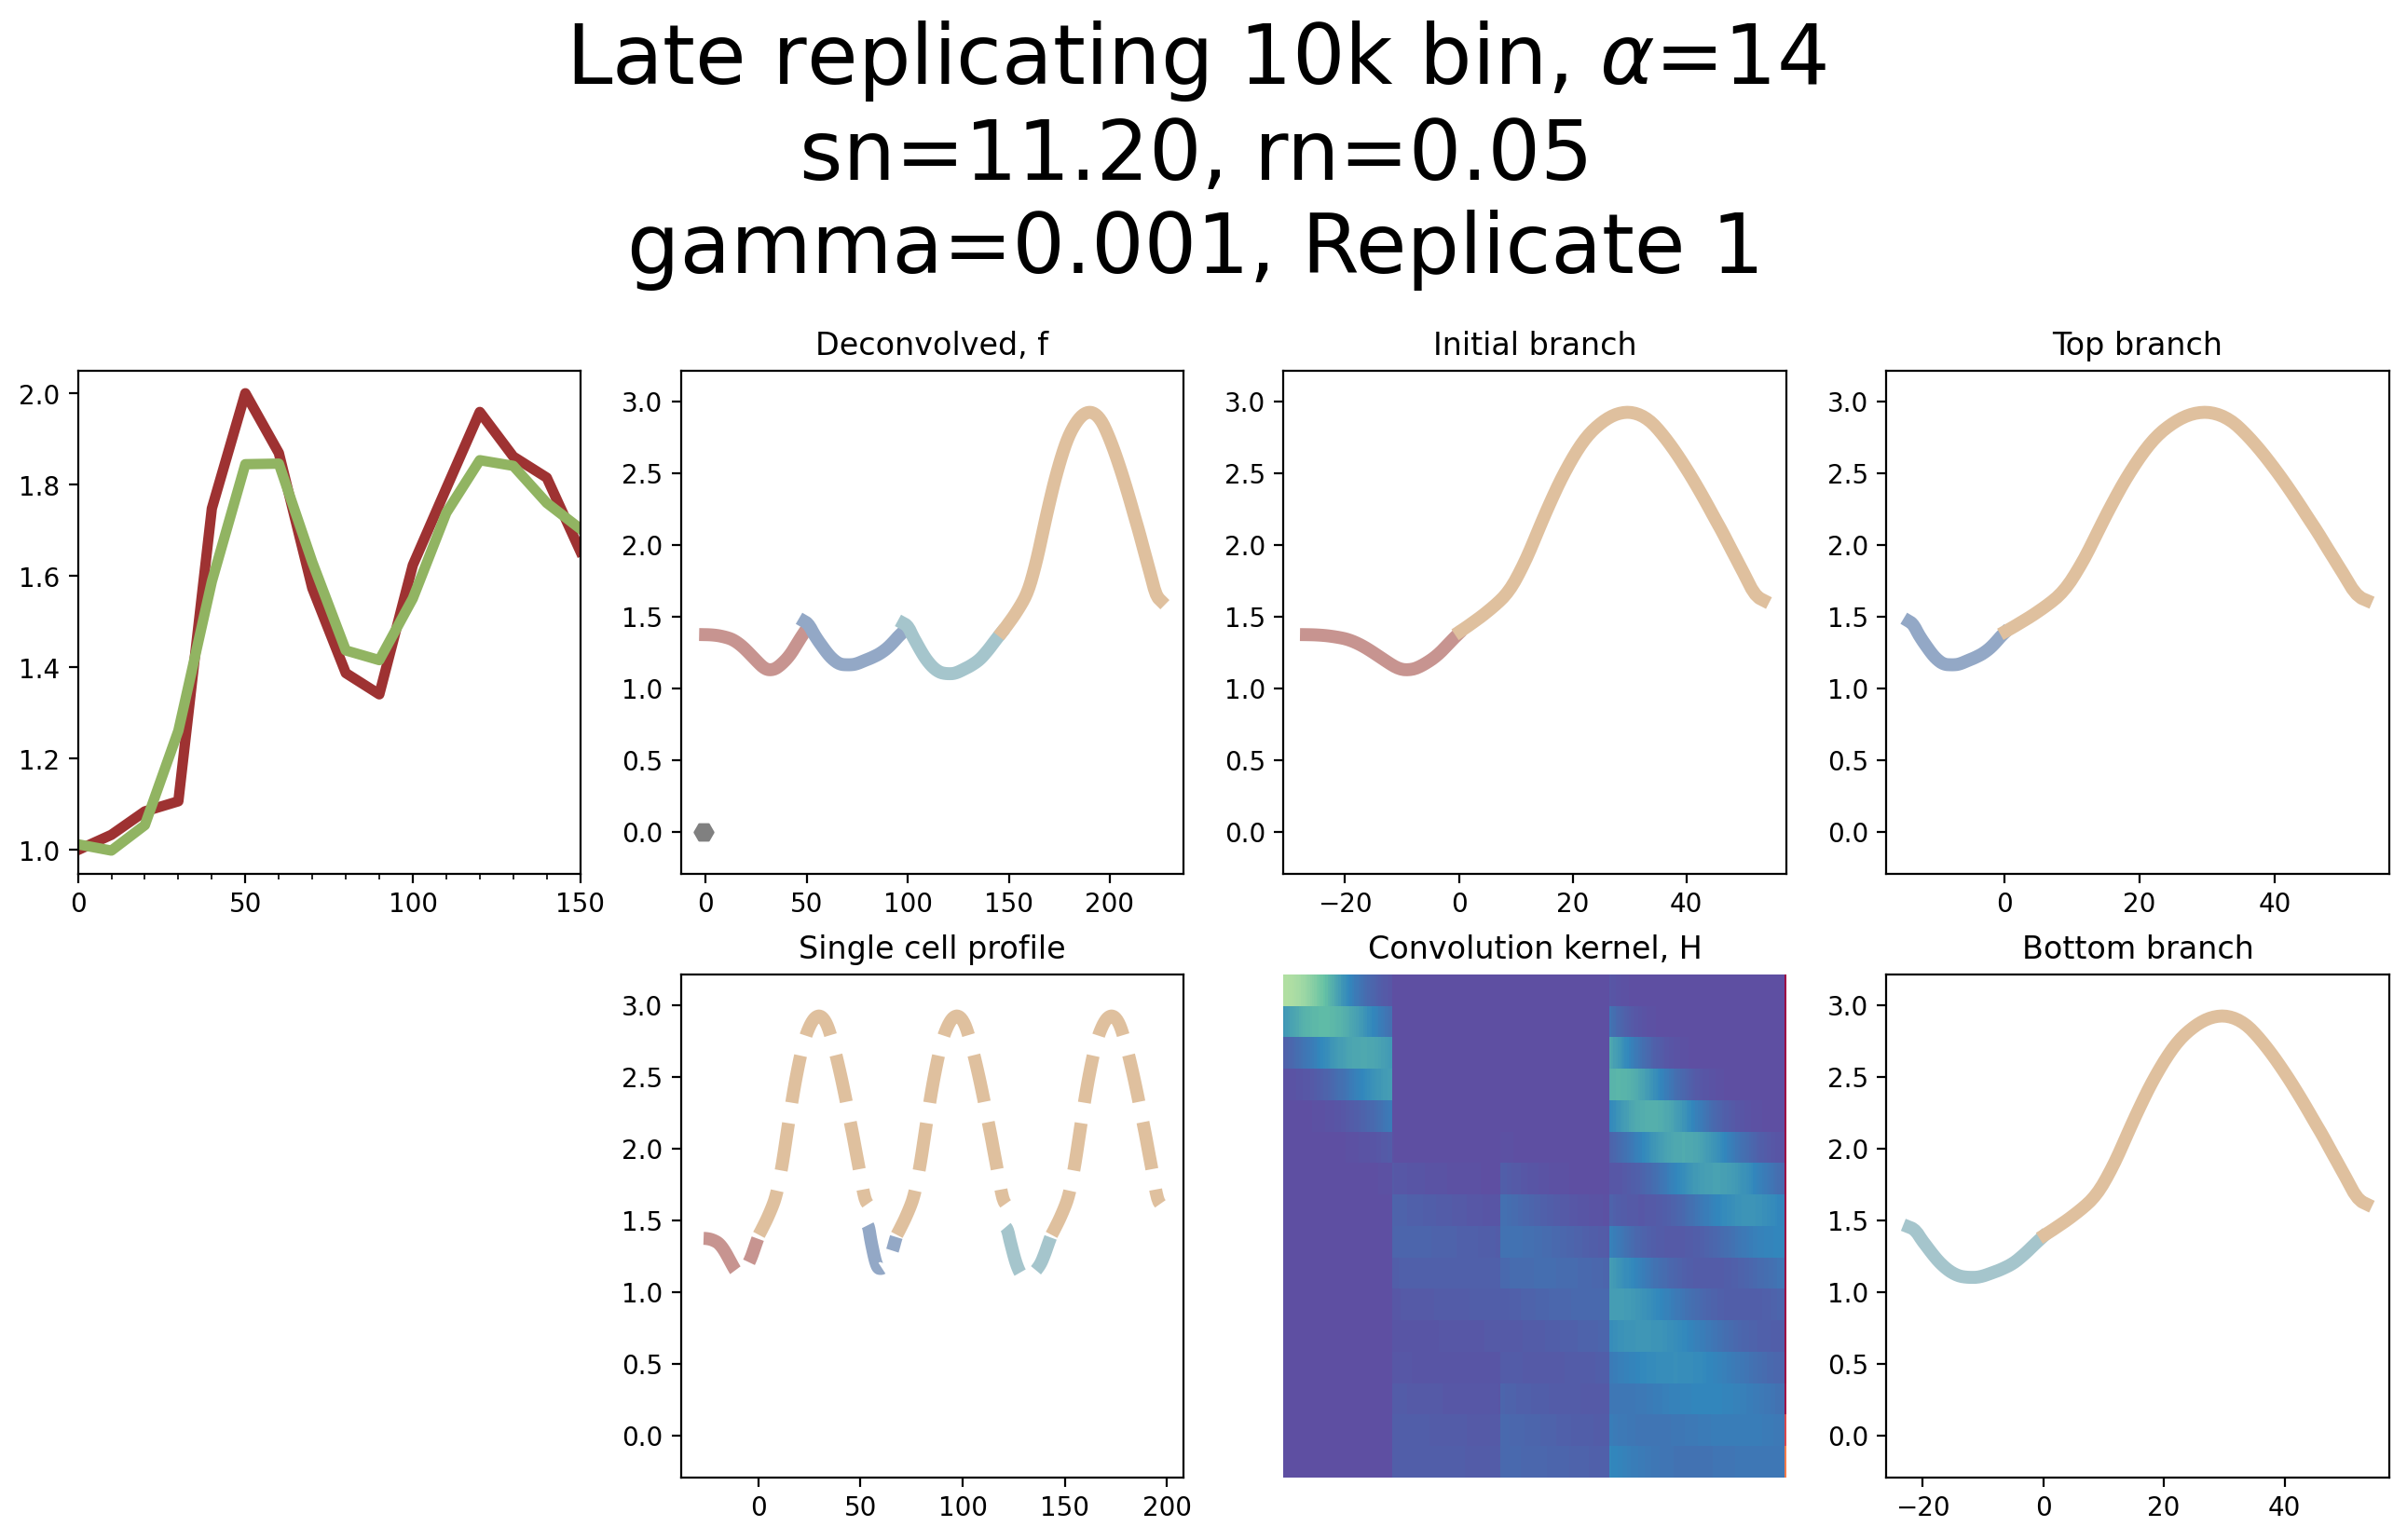

In [749]:
compare_early_late_deconv_bin_curves(14)

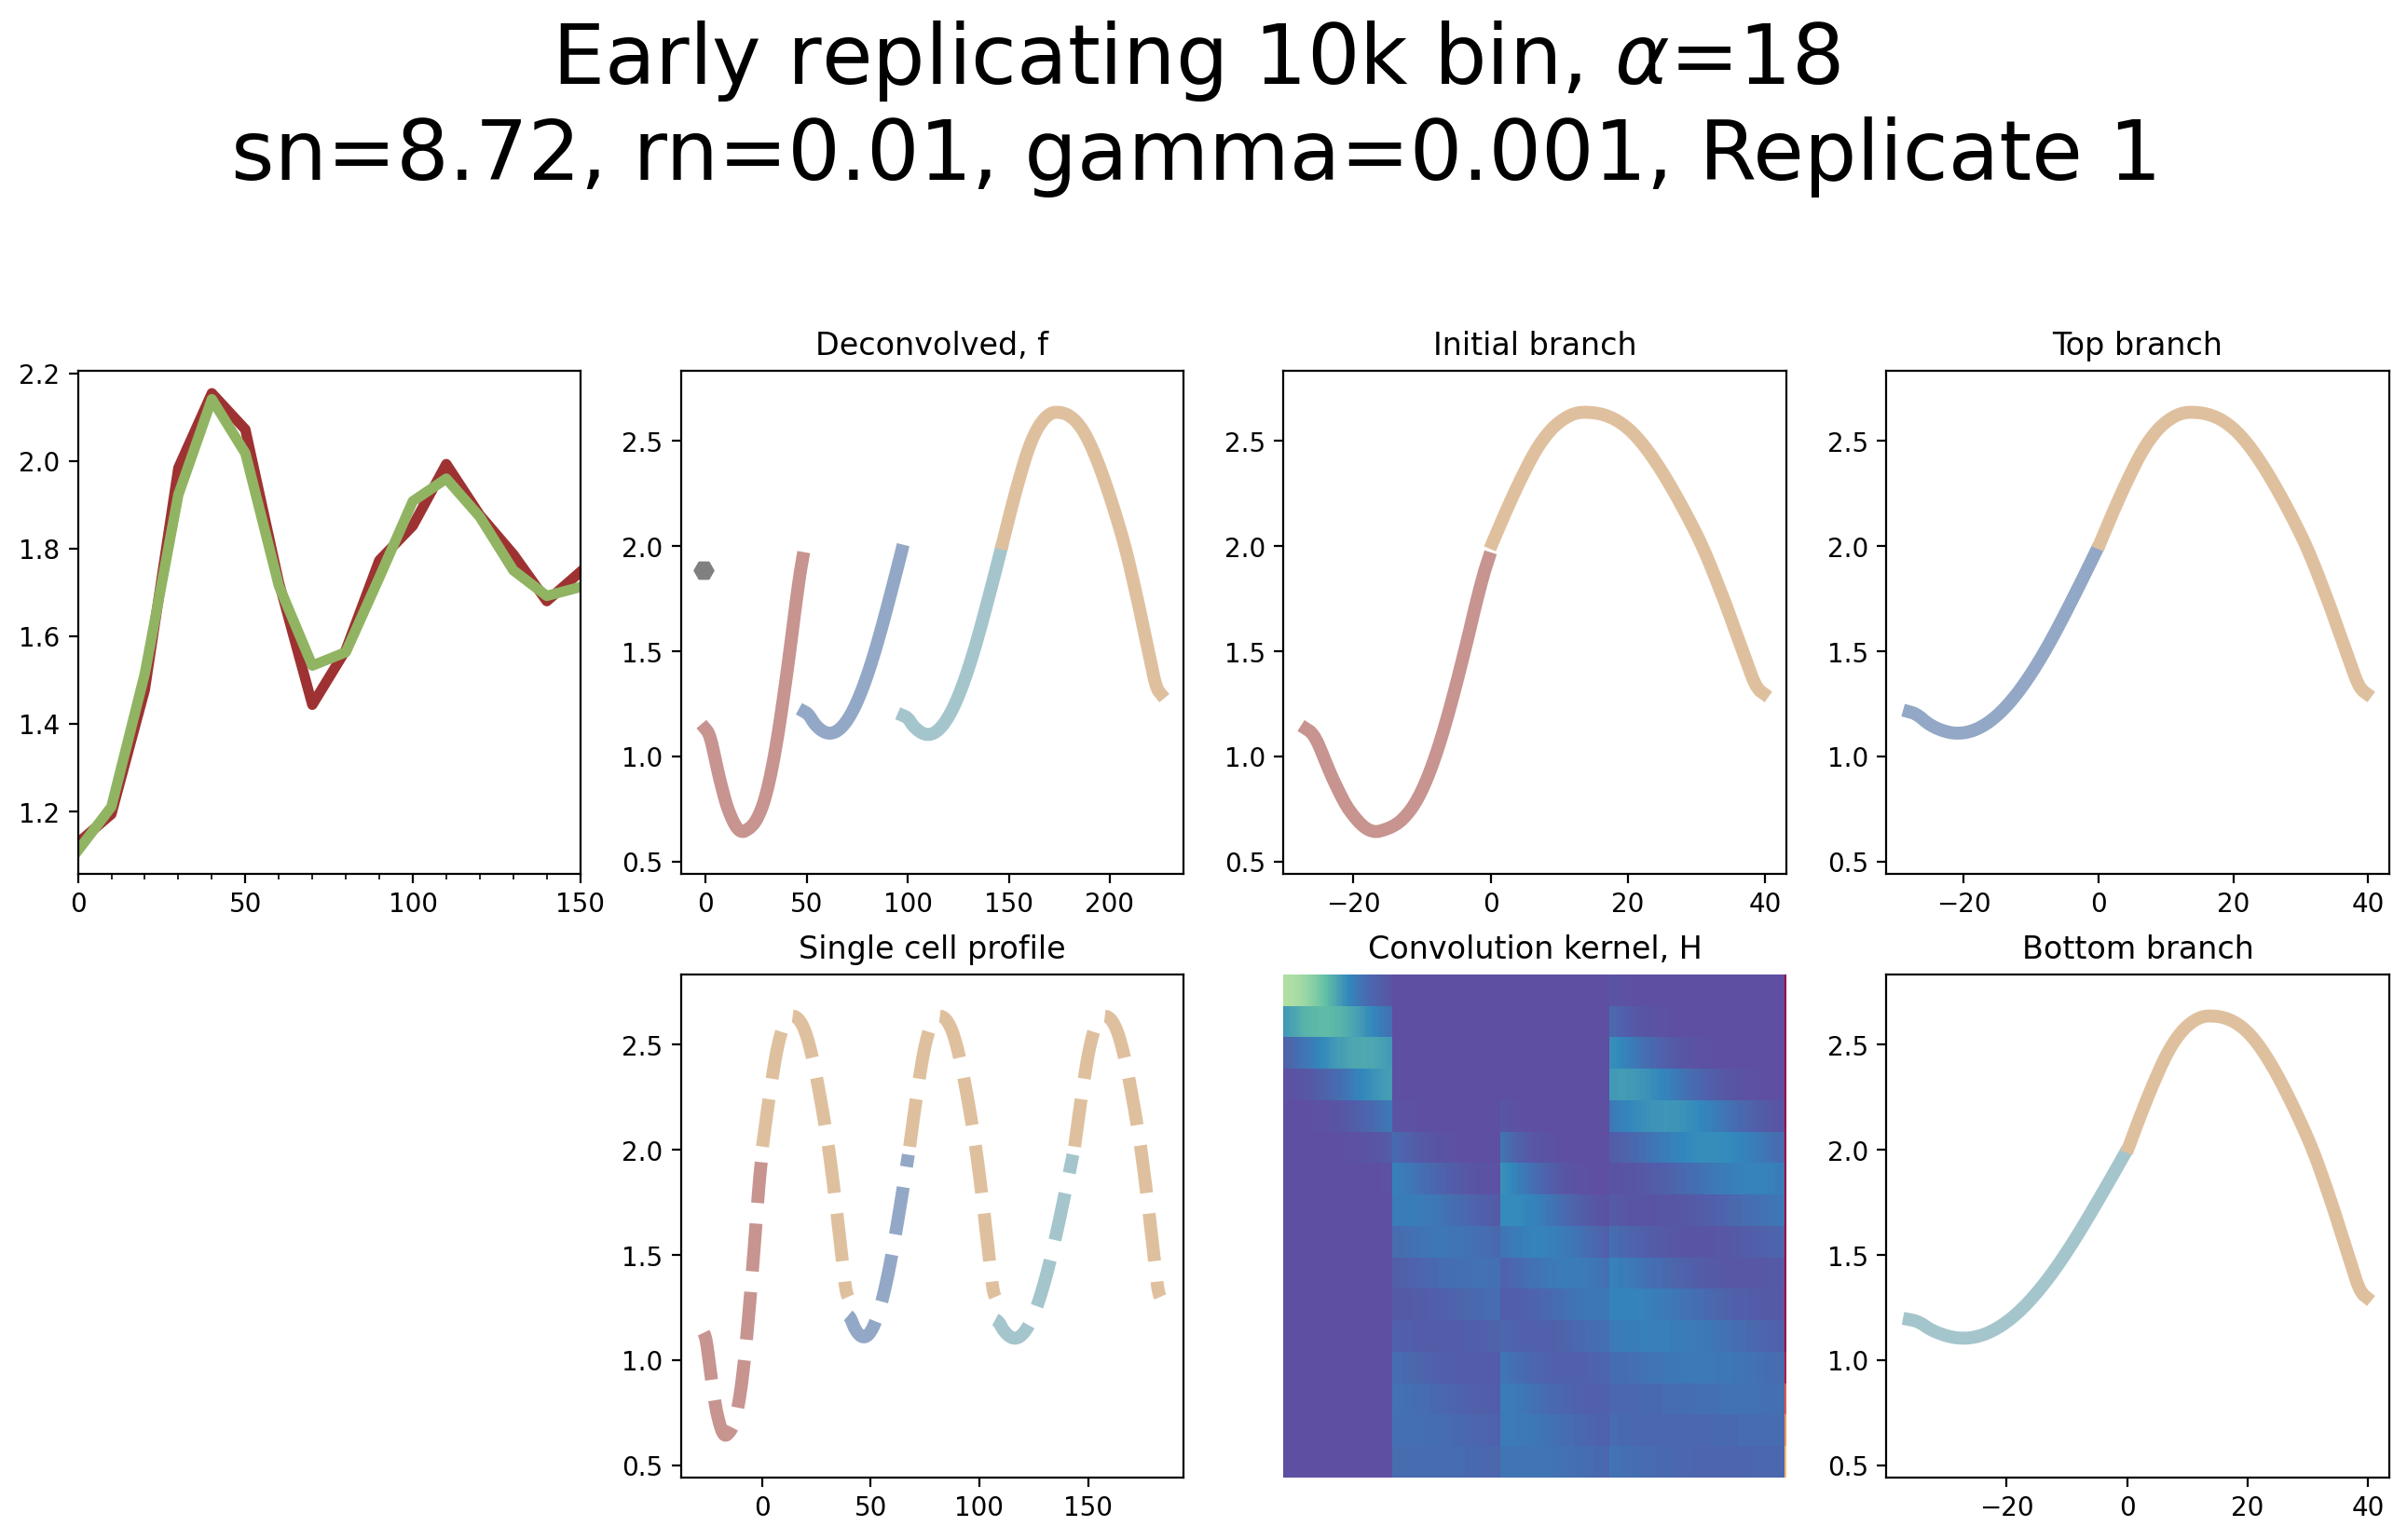

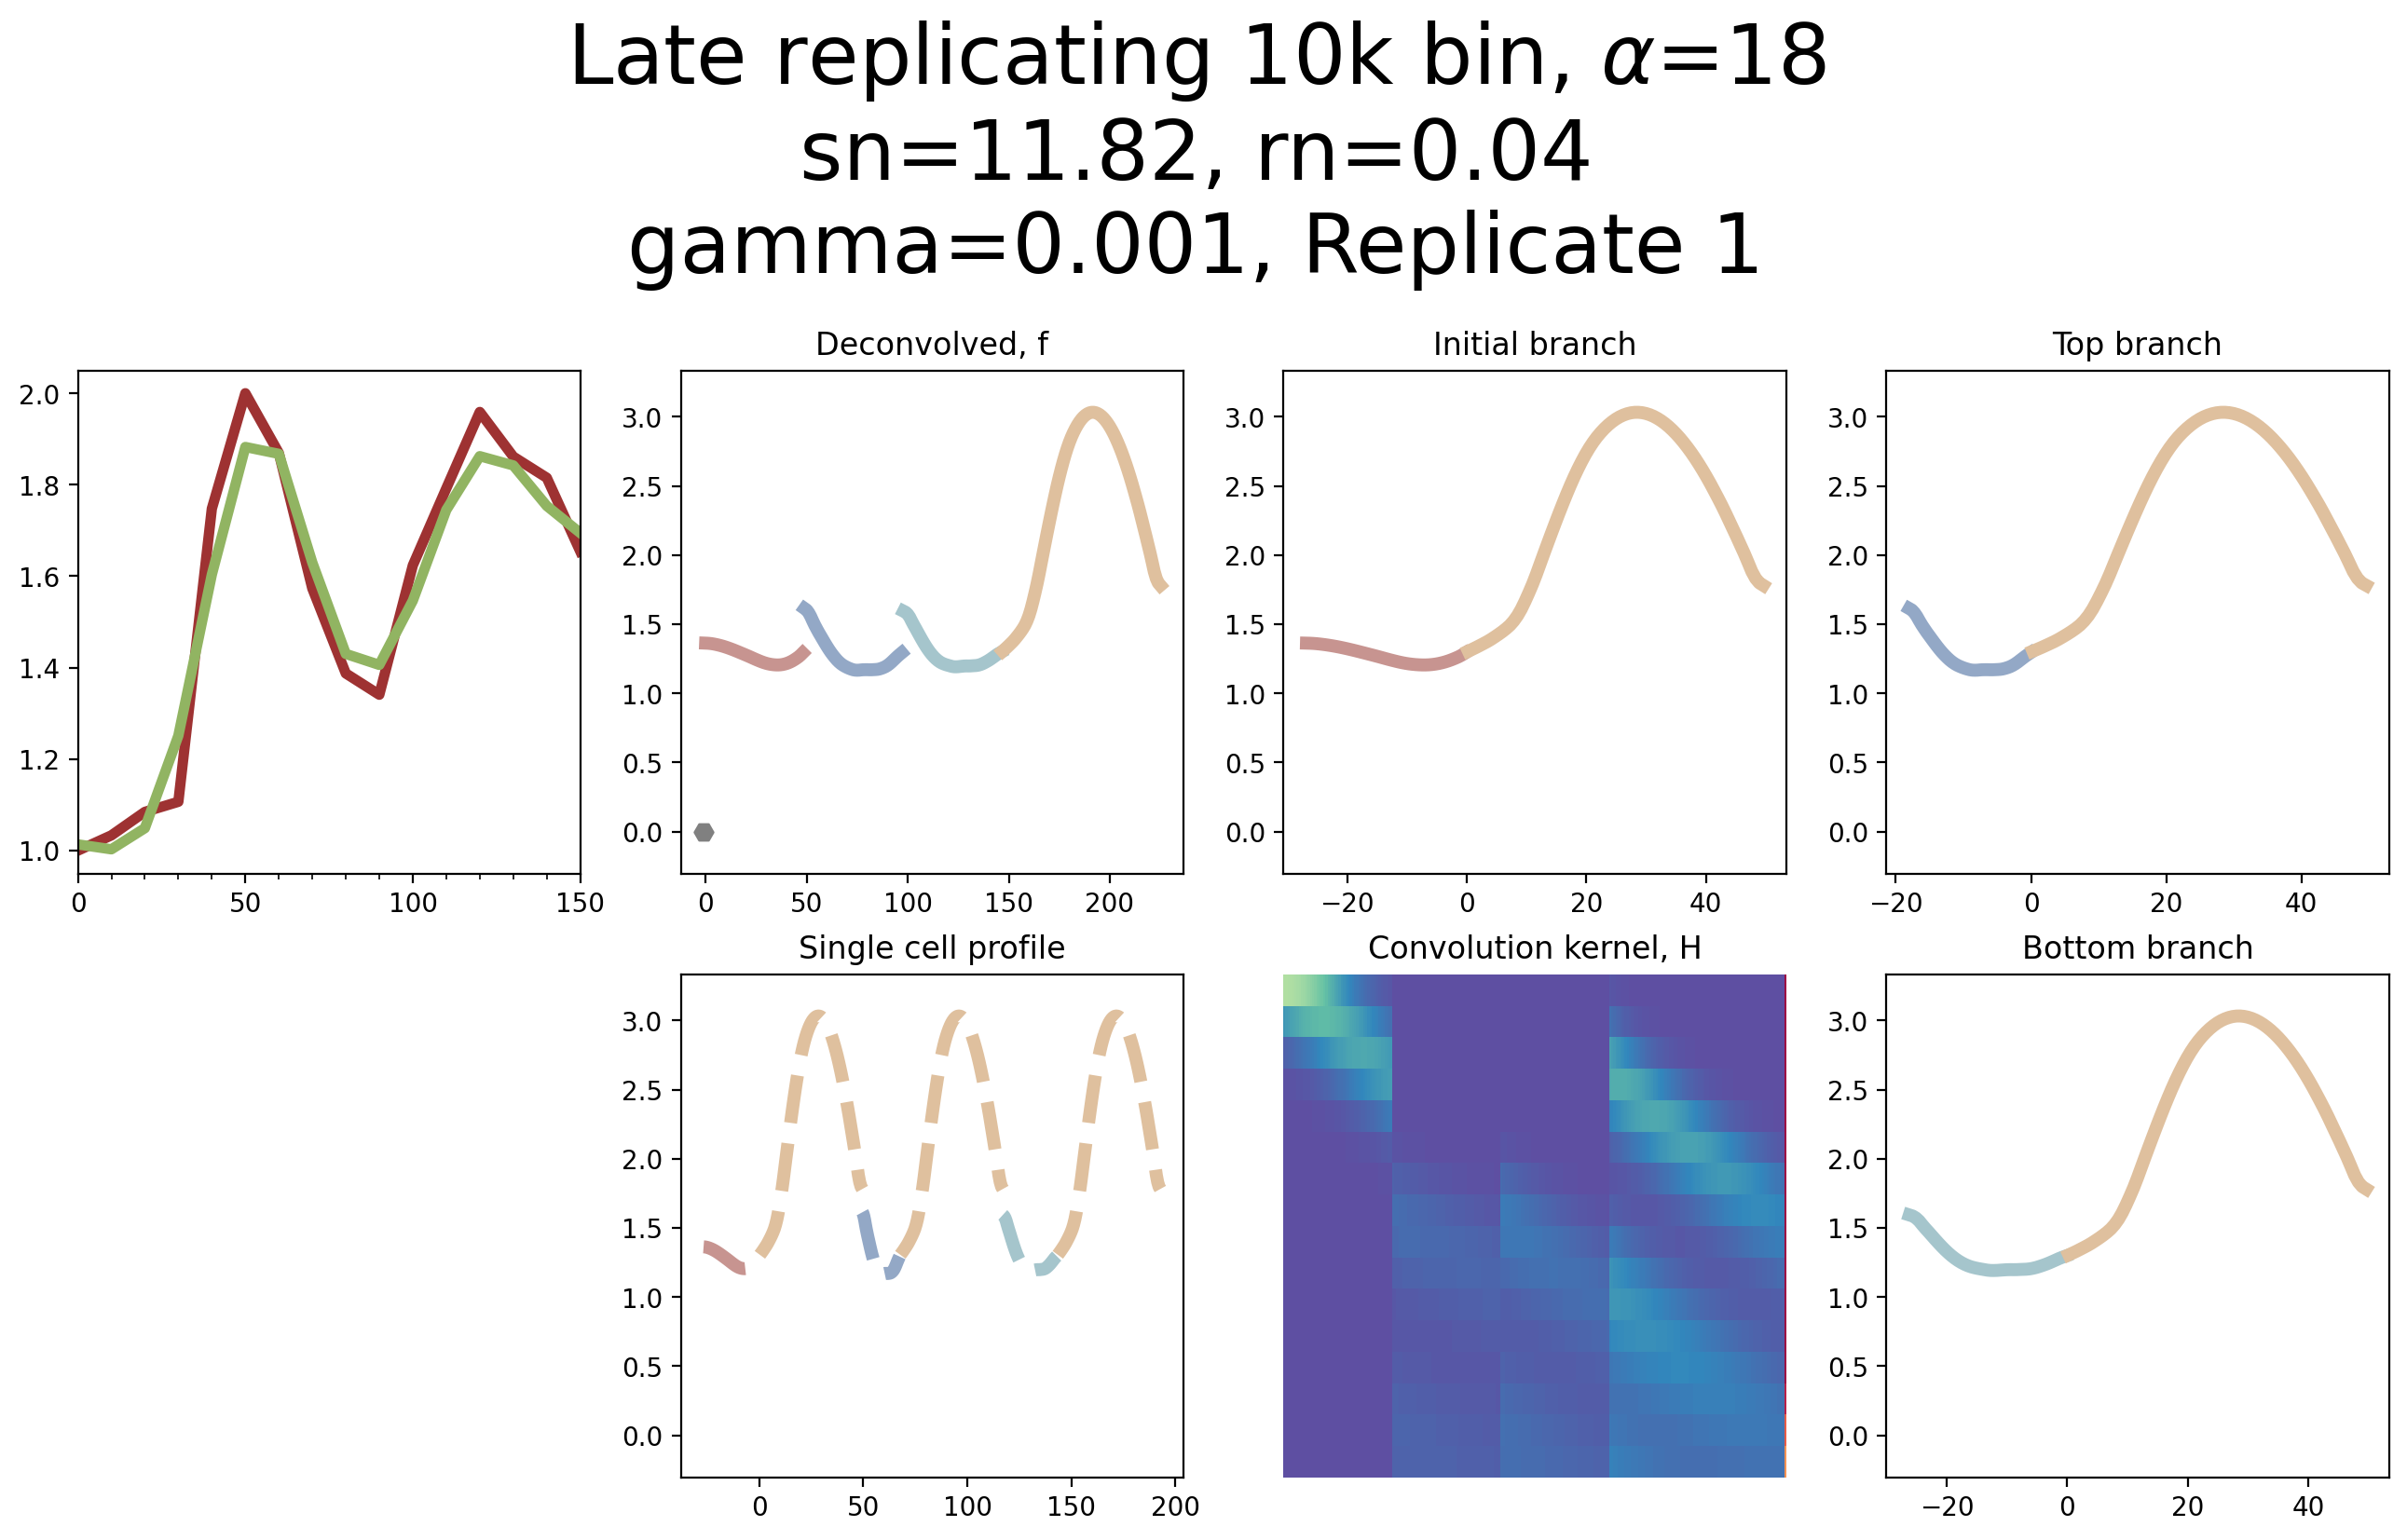

In [750]:
compare_early_late_deconv_bin_curves(18)

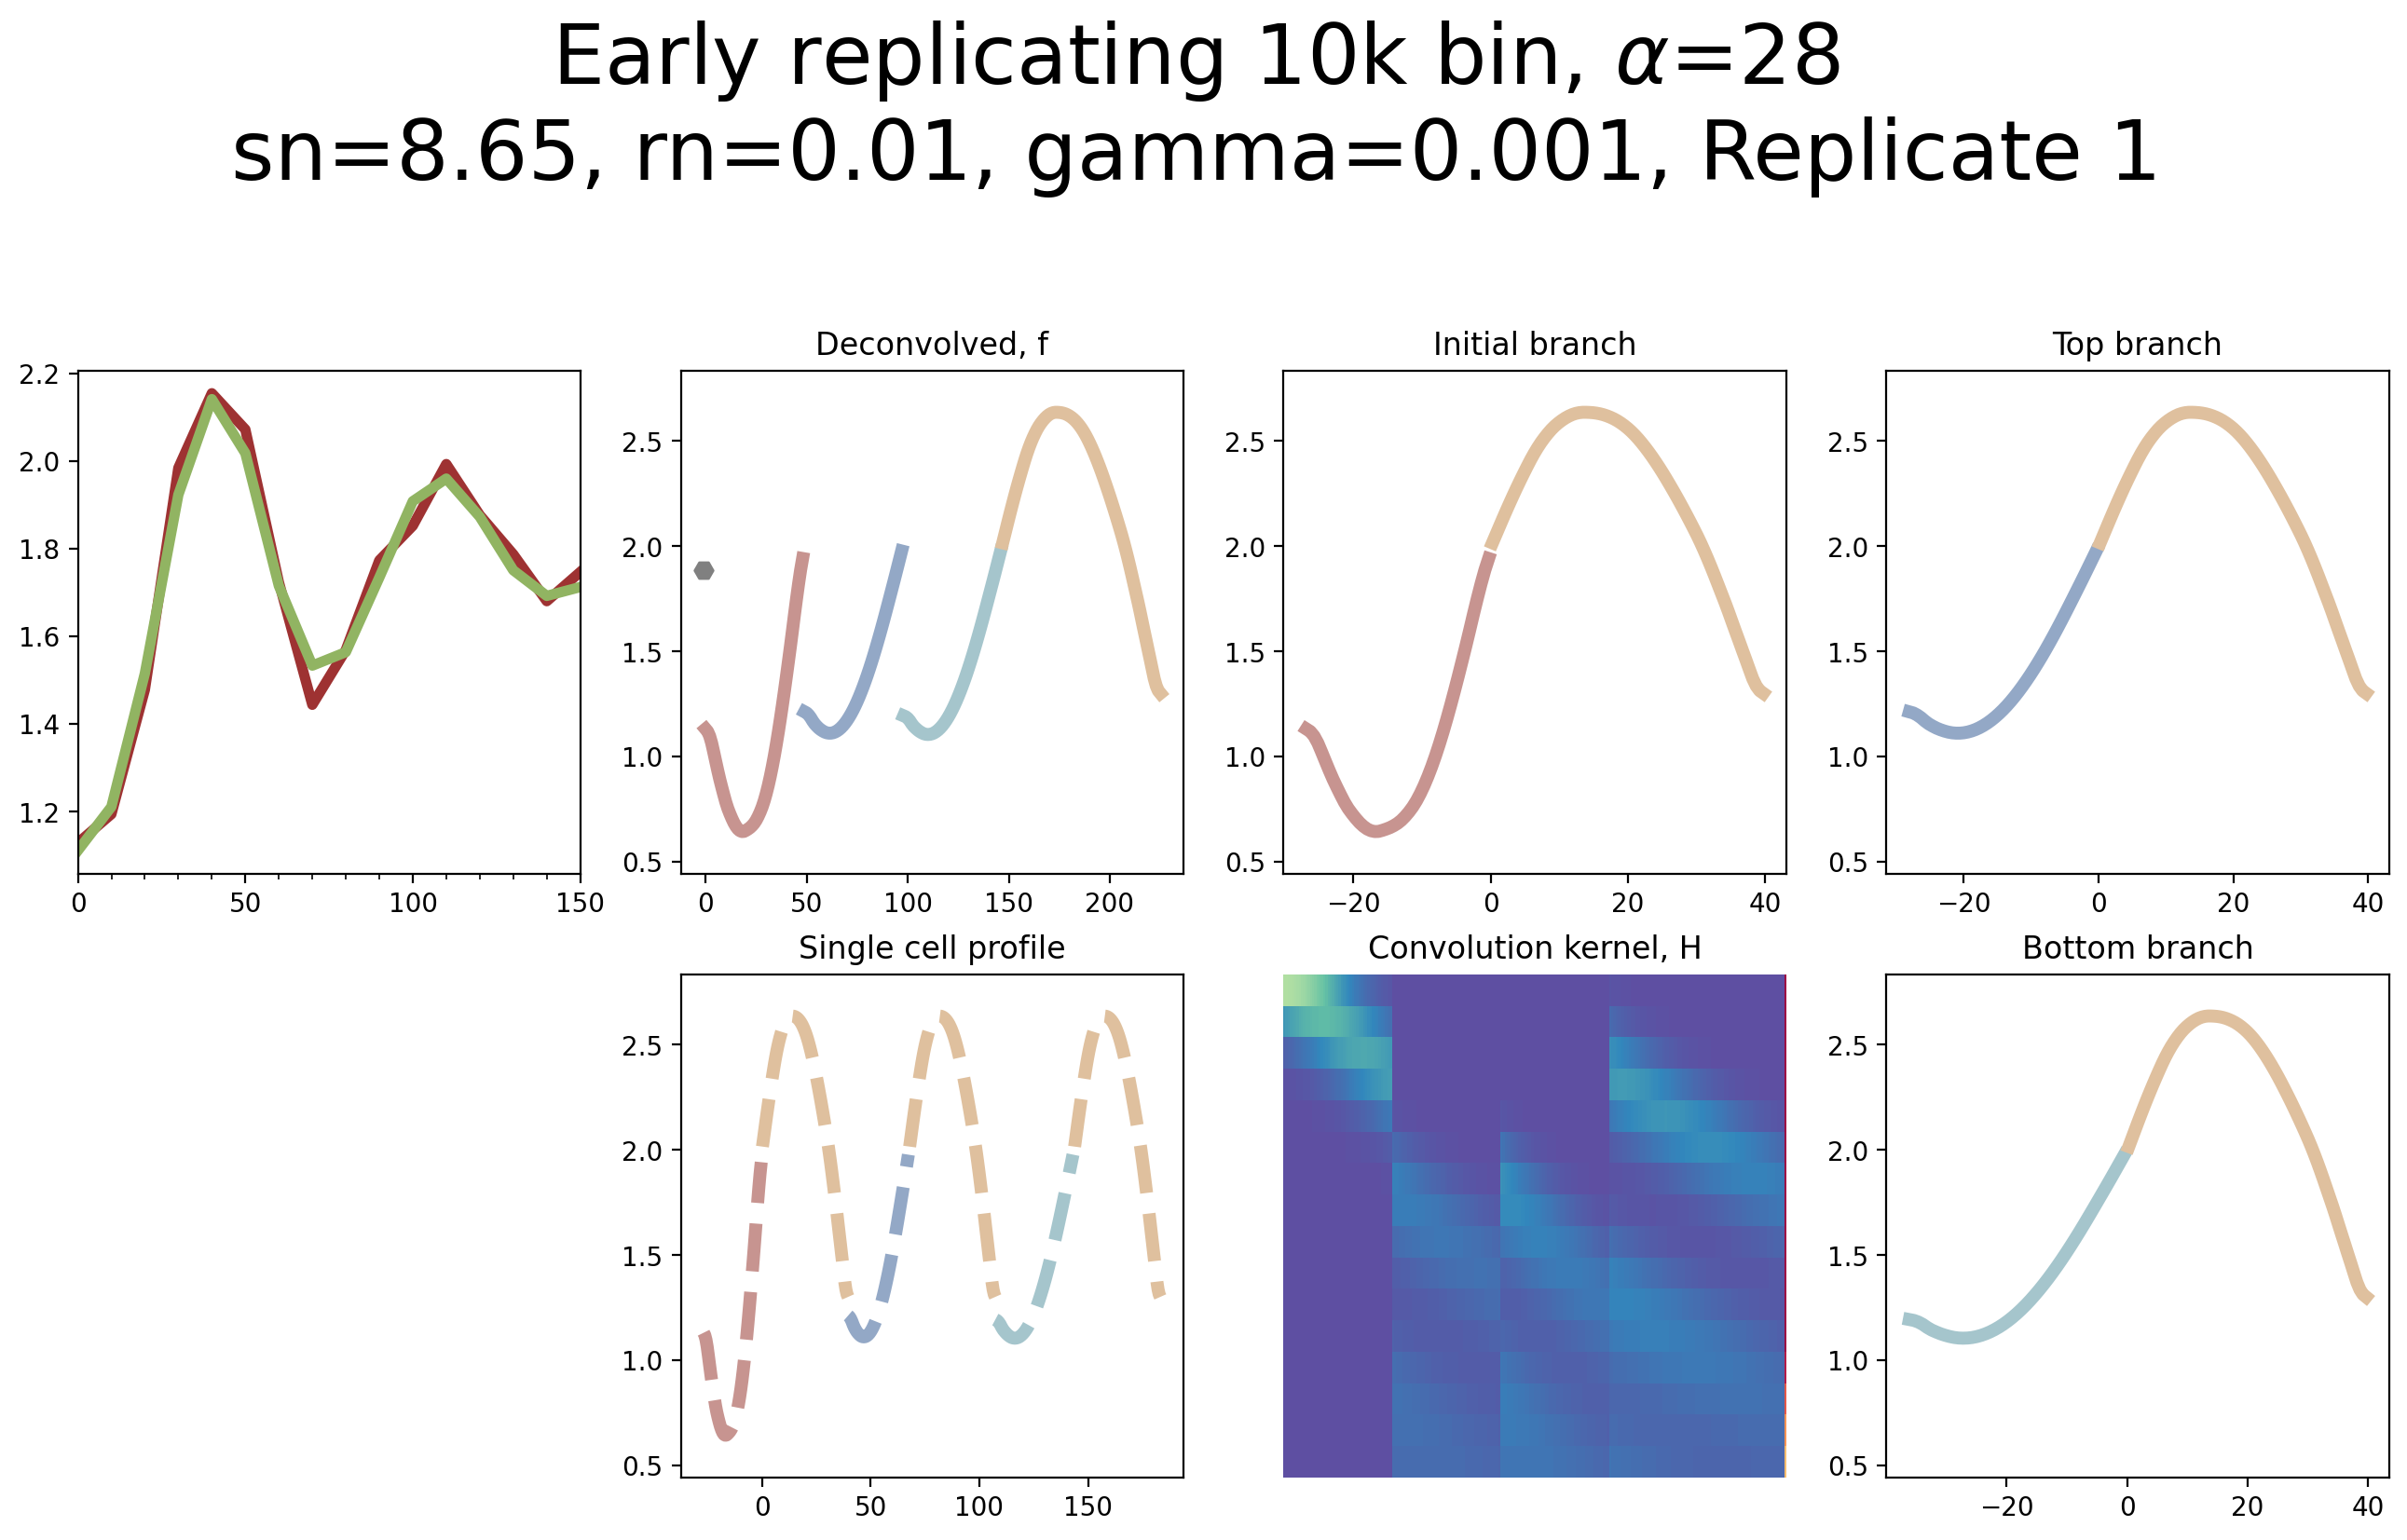

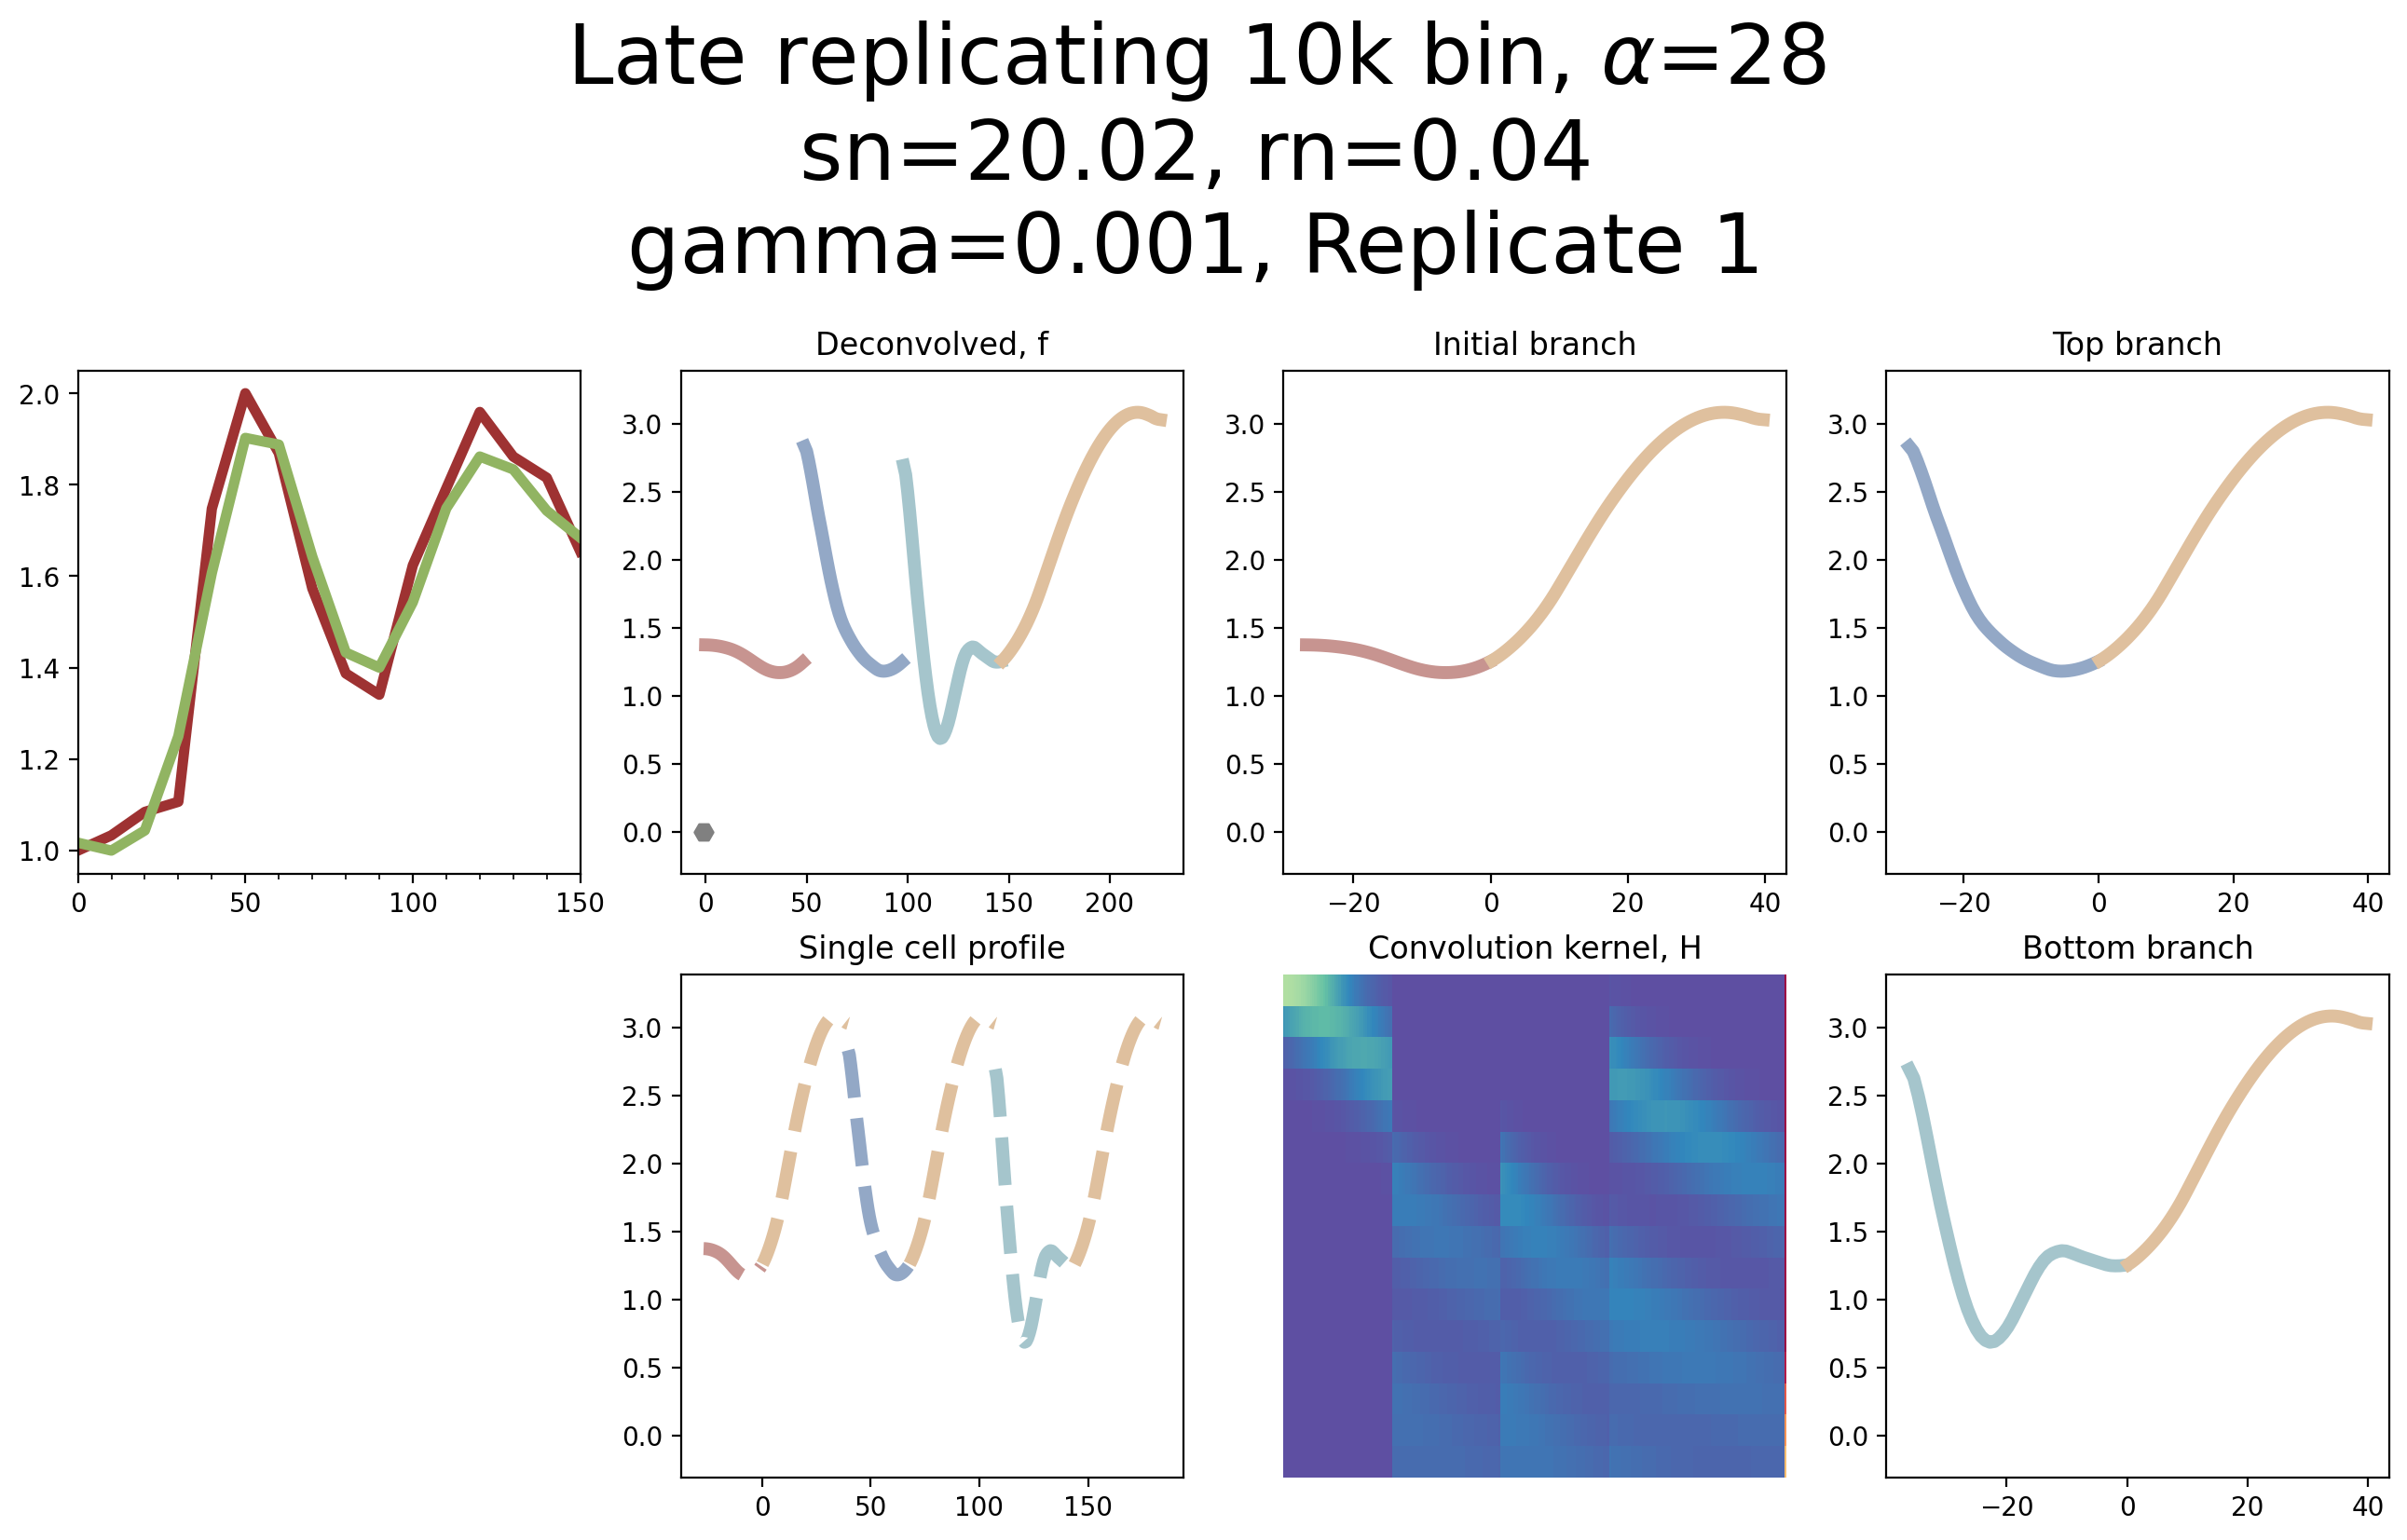

In [751]:
compare_early_late_deconv_bin_curves(28)

In [1024]:
dynamic_config = create_dynamic_alpha_config(8, 1)
gene_name = "DSE4"
model = Model(dynamic_config, gene_name)
model.deconvolve_find_optimal_gamma()

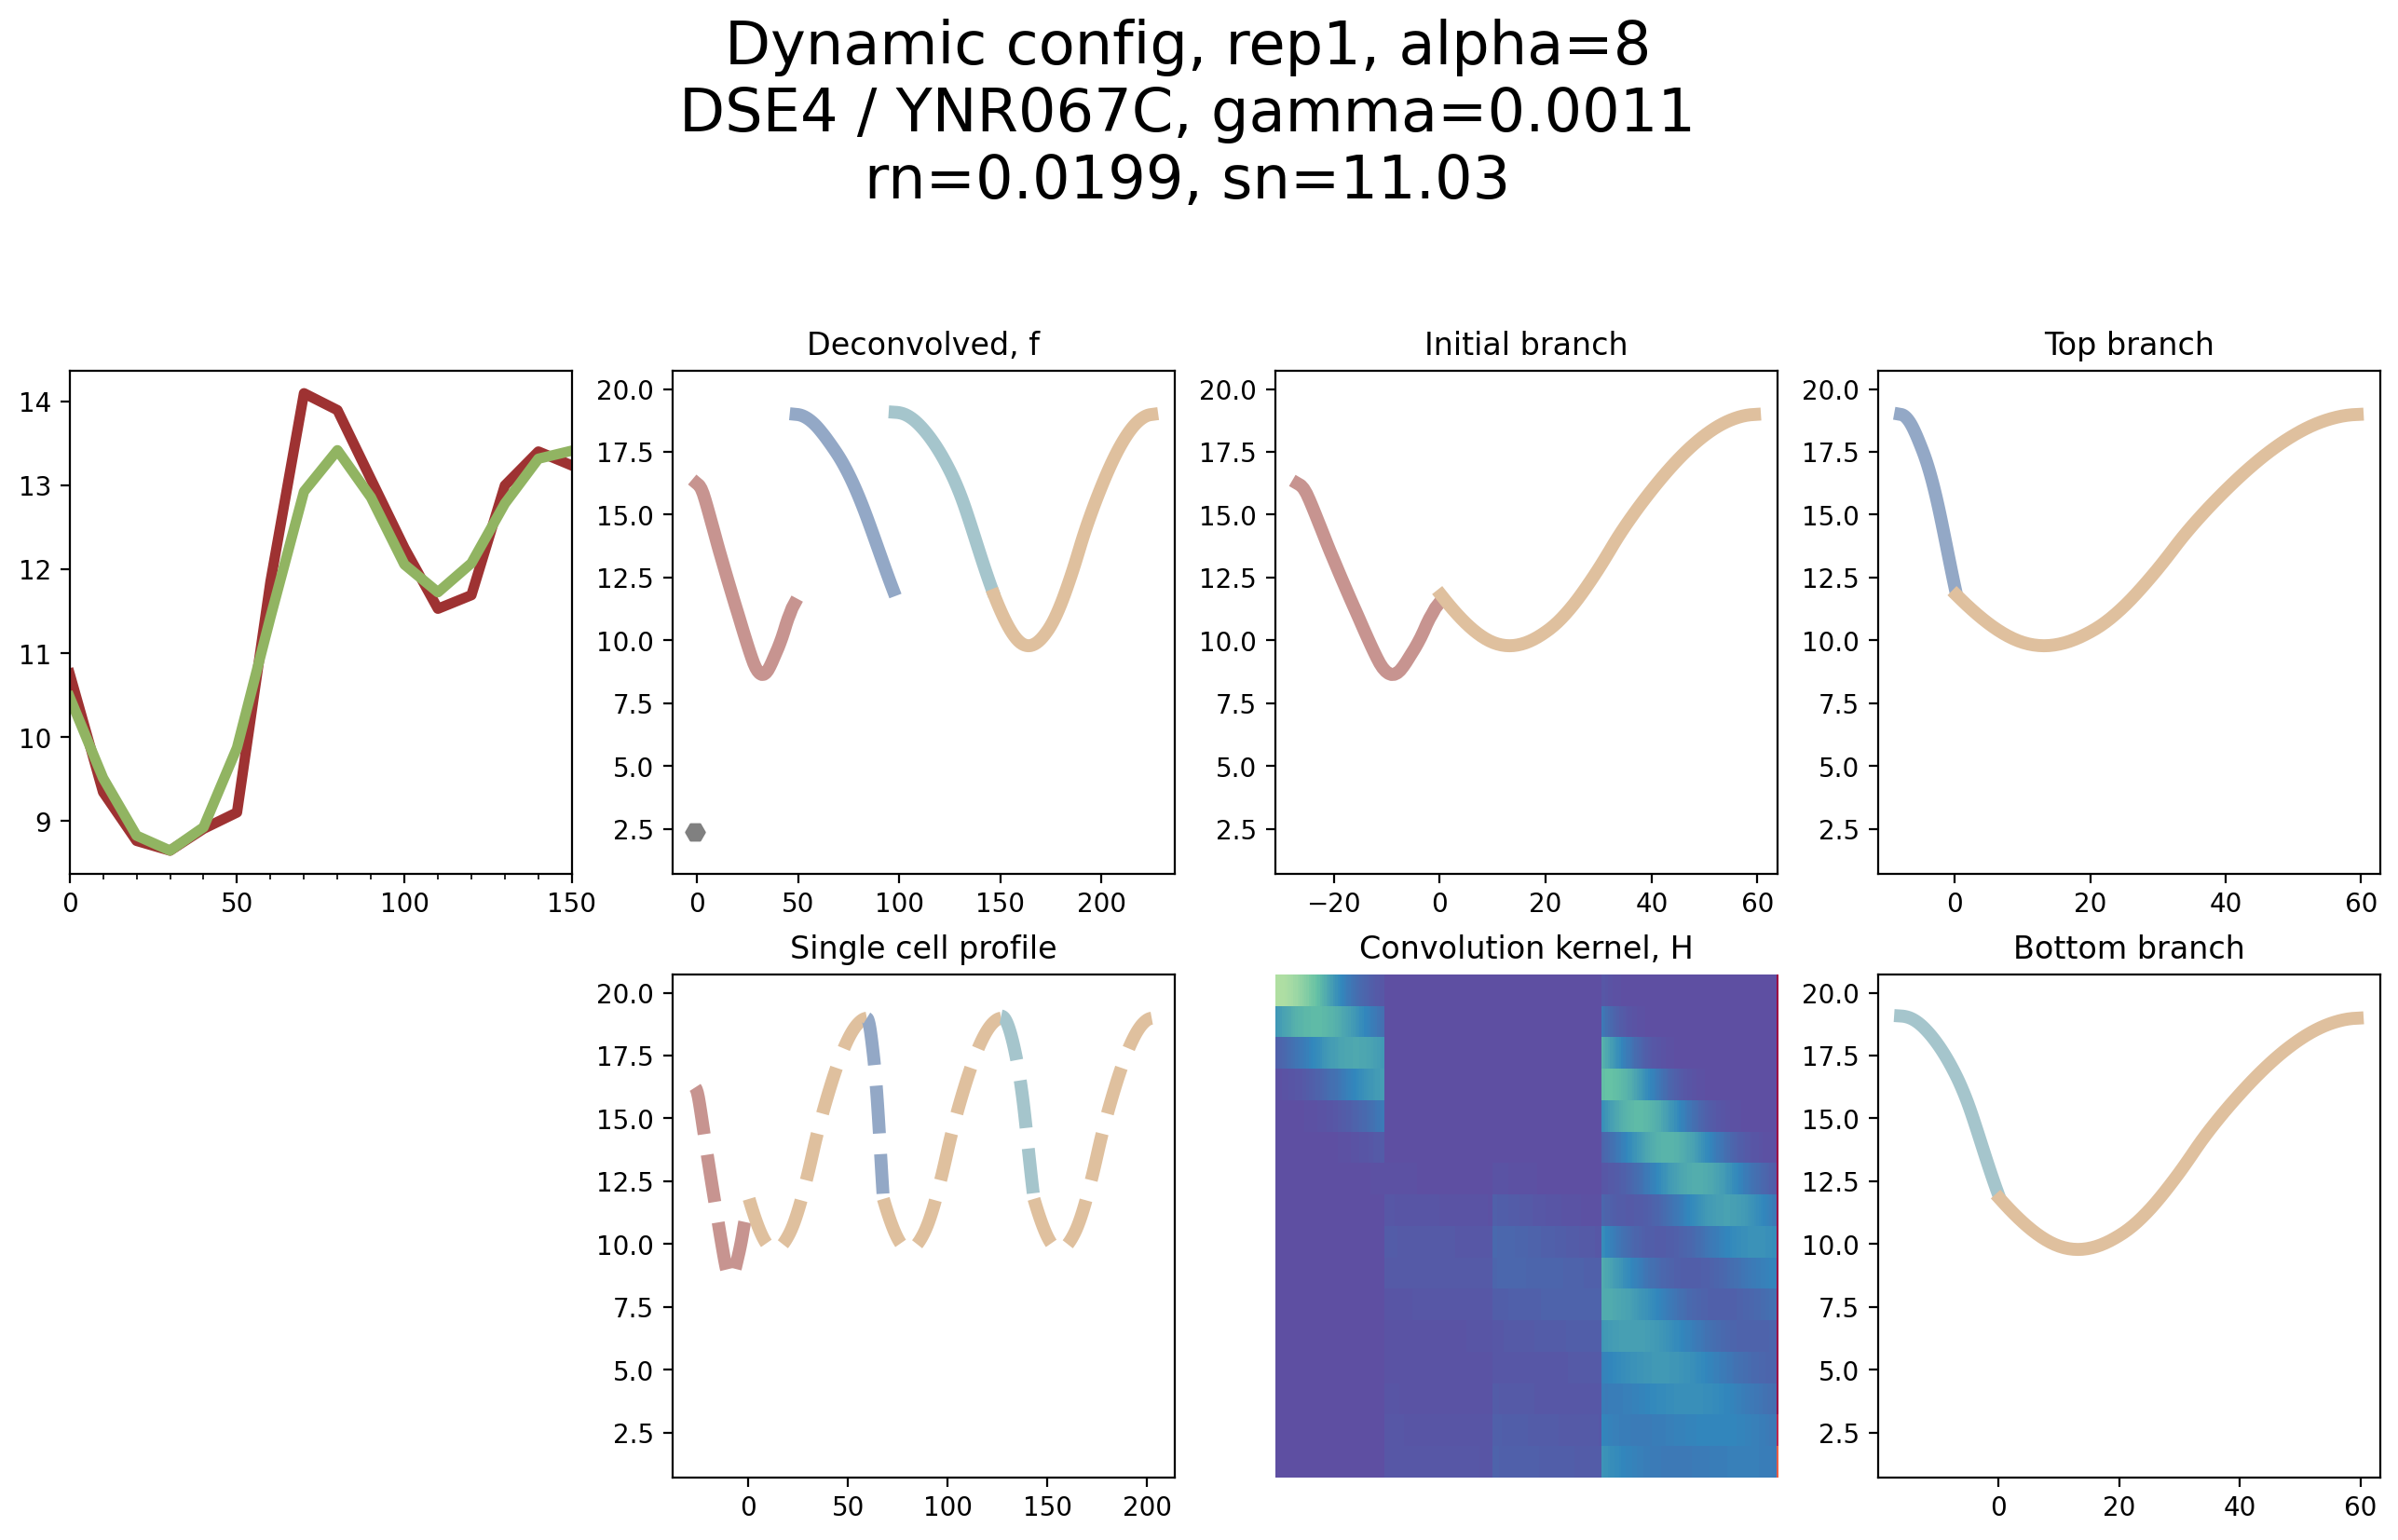

In [1025]:
_ = model.plot_deconvolved_gene()

In [949]:
from src.geneset import get_deconvolved_geneset
geneset = get_deconvolved_geneset()

bin_curves_G_df = mnase_analysis_rep1.normalized_bin_curves.dropna()
chr_bin_curves = bin_curves_G_df.join(geneset[geneset['chr'] == 4][[]], how='inner')

In [822]:
i_indices = config.get_Hpositions_for_branch('i')
t_indices = config.get_Hpositions_for_branch('t')
b_indices = config.get_Hpositions_for_branch('b')

cg1_ind = config.get_Hpositions_for_phase('CG1')
dg1_ind = config.get_Hpositions_for_phase('DG1')
postG1_ind = config.get_Hpositions_for_phase('postG1')

In [958]:

from src.chromatin_model import ChromatinModel

# Deconvolve the normalized bin curves, will this allow for us 
# to create a more high resolution replication timing profile?
config = create_dynamic_alpha_config(18, 1)
chrom_model = ChromatinModel(config)

# Let's try different values of alpha

def get_f_for_alpha(alpha):
        
    config = create_dynamic_alpha_config(alpha, 1)
    
    # Set the config to the updated alpha
    chrom_model.config = config
    chrom_model.create_deconvolution_bins()
    
    # set G to the bin curves 
    chrom_model.G = chr_bin_curves.T.values+1.
    
    chrom_model.setup_deconv_model()
    chrom_model.gamma = 0.001
    chrom_model.deconvolve()

    f = chrom_model.deconvolved_f()

    return f


In [968]:
u, m = chr_bin_curves.shape[0], chrom_model.deconv_model.H.shape[1]
alphas = np.arange(0, 30, 2)
alpha_fs = np.zeros((len(alphas), m, u))

print(alpha_fs.shape)

for i in range(len(alphas)):
    alpha = alphas[i]
    print(f"{i}/{len(alphas)}")
    deconvolved_f = get_f_for_alpha(alpha)
    alpha_fs[i] = deconvolved_f


(15, 227, 706)
0/15
Deconvolving with gamma=0.001, gamma_prime=0
Deconvolved in : 00:01:43.894
The fitting norm is 0.11, the smoothing norm is: 19.47
1/15
Deconvolving with gamma=0.001, gamma_prime=0
Deconvolved in : 00:01:40.044
The fitting norm is 0.13, the smoothing norm is: 17.63
2/15
Deconvolving with gamma=0.001, gamma_prime=0
Deconvolved in : 00:01:39.052
The fitting norm is 0.12, the smoothing norm is: 17.00
3/15
Deconvolving with gamma=0.001, gamma_prime=0
Deconvolved in : 00:01:38.866
The fitting norm is 0.12, the smoothing norm is: 16.29
4/15
Deconvolving with gamma=0.001, gamma_prime=0
Deconvolved in : 00:01:39.395
The fitting norm is 0.10, the smoothing norm is: 16.18
5/15
Deconvolving with gamma=0.001, gamma_prime=0
Deconvolved in : 00:01:46.099
The fitting norm is 0.10, the smoothing norm is: 15.27
6/15
Deconvolving with gamma=0.001, gamma_prime=0
Deconvolved in : 00:01:41.648
The fitting norm is 0.12, the smoothing norm is: 14.71
7/15
Deconvolving with gamma=0.001, gamm

Text(0.5, 1.0, 'Determining Alpha from CG1/DG1')

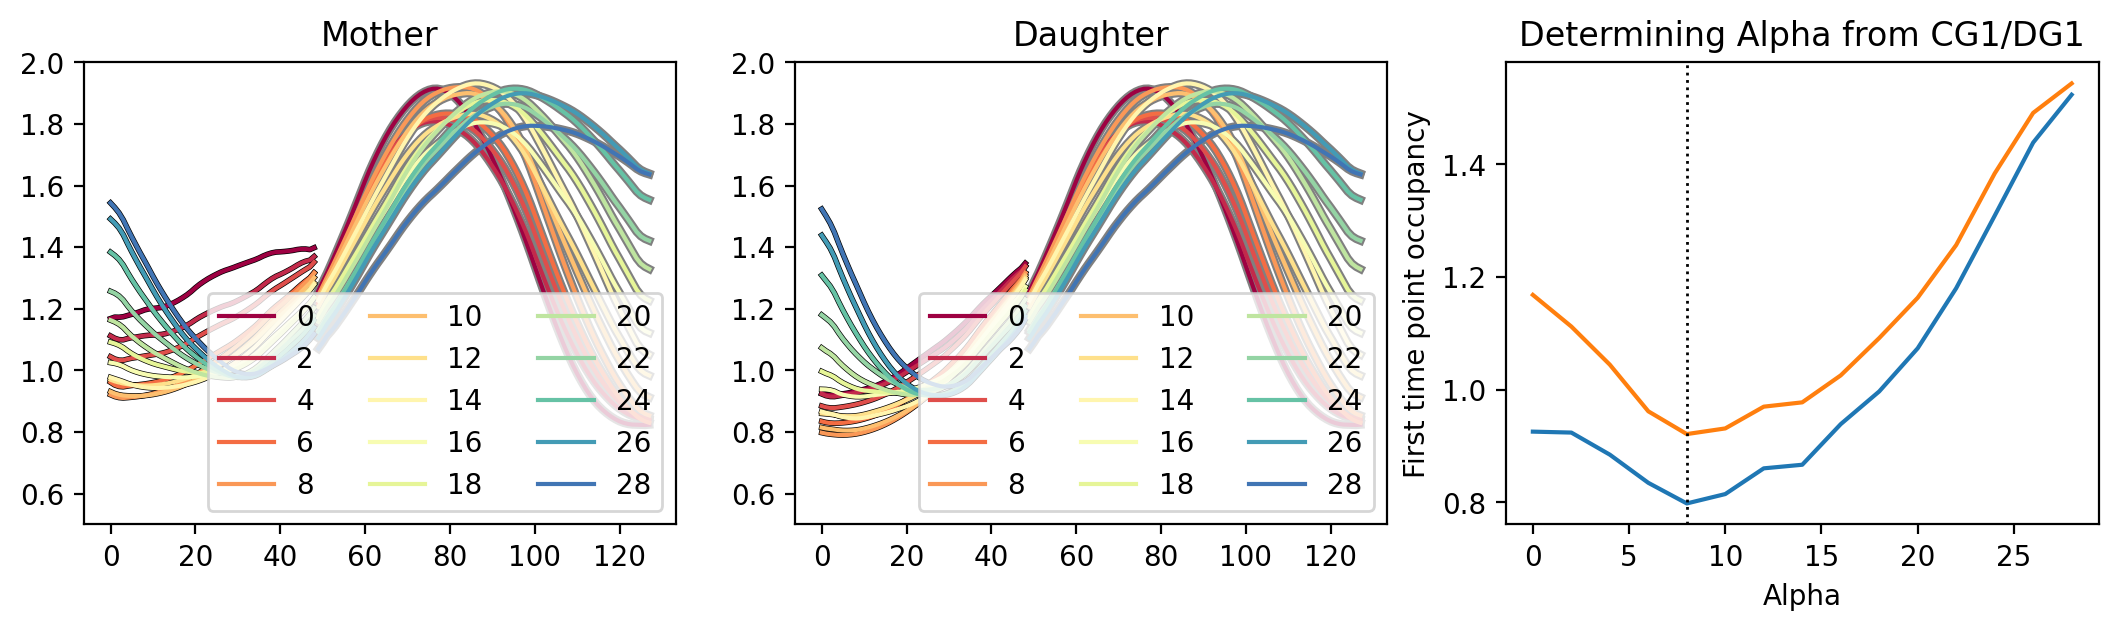

In [1021]:
def plot_alpha_avg(g1_indices, alpha_fs, i, alphas):
    color = plt.get_cmap('Spectral')(i/len(alphas))
    alpha = alphas[i]
    dg1 = alpha_fs[i][g1_indices].mean(axis=1)
    postg1 = alpha_fs[i][postG1_ind].mean(axis=1)
    
    plt.plot(np.arange(len(dg1)), dg1, c='black', lw=2, zorder=1)
    plt.plot(np.arange(len(postg1)) + len(dg1), postg1, c='gray', lw=3, zorder=1)
    
    plt.plot(np.arange(len(dg1)), dg1, c=color)
    plt.plot(np.arange(len(postg1)) + len(dg1), postg1, c=color, label=alpha)
    plt.ylim(0.5, 2.)
    plt.legend(ncol=3)

plt.figure(figsize=(13, 3))
plt.subplot(1, 3, 1)
for i in range(len(alphas)):
    plot_alpha_avg(cg1_indices, alpha_fs, i, alphas)
plt.title("Mother")

plt.subplot(1, 3, 2)
for i in range(len(alphas)):
    plot_alpha_avg(dg1_indices, alpha_fs, i, alphas)
plt.title("Daughter")


mean_dg1 = alpha_fs[:, dg1_ind[0], :].mean(axis=1)
mean_cg1 = alpha_fs[:, cg1_ind[0], :].mean(axis=1)

plt.subplot(1, 3, 3)
plt.plot(alphas, mean_dg1, label="DG1 first tp")
plt.plot(alphas, mean_cg1, label="CG1 first tp")

min_ind = np.argmin(mean_cg1)
min_alpha = alphas[min_ind]
plt.axvline(min_alpha, c='black', lw=1, ls='dotted')
plt.xlabel("Alpha")
plt.ylabel("First time point occupancy")
plt.title("Determining Alpha from CG1/DG1")

Text(0.5, 0.98, 'Deconvolved gene replication profile, chr4, replicate 1, alpha=8')

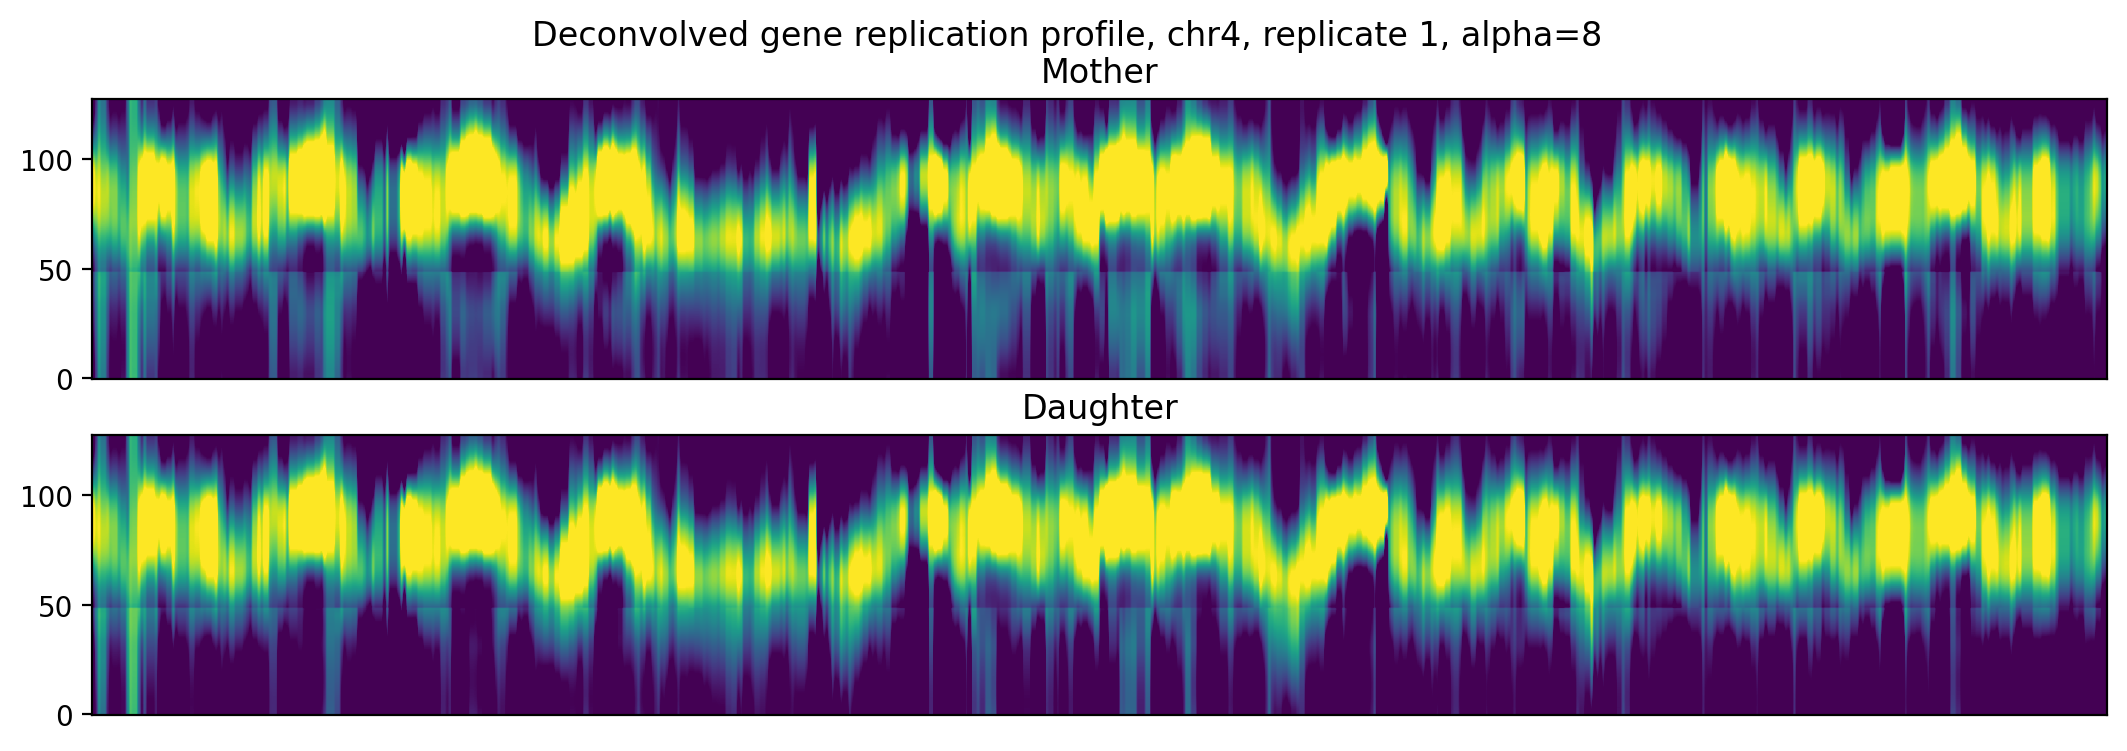

In [1026]:
plt.figure(figsize=(13, 4))

plt.subplot(2, 1, 1)
plt.imshow(alpha_fs[min_ind][t_indices], origin='lower', vmin=1, vmax=2, aspect='auto')
plt.title("Mother")
plt.xticks([])

plt.subplot(2, 1, 2)
plt.imshow(alpha_fs[min_ind][b_indices], origin='lower', vmin=1, vmax=2, aspect='auto')
plt.title("Daughter")
plt.xticks([])

plt.suptitle("Deconvolved gene replication profile, chr4, replicate 1, alpha=8")


Text(0.5, 0.98, 'Deconvolved gene replication profile, chr4, replicate 1, alpha=28')

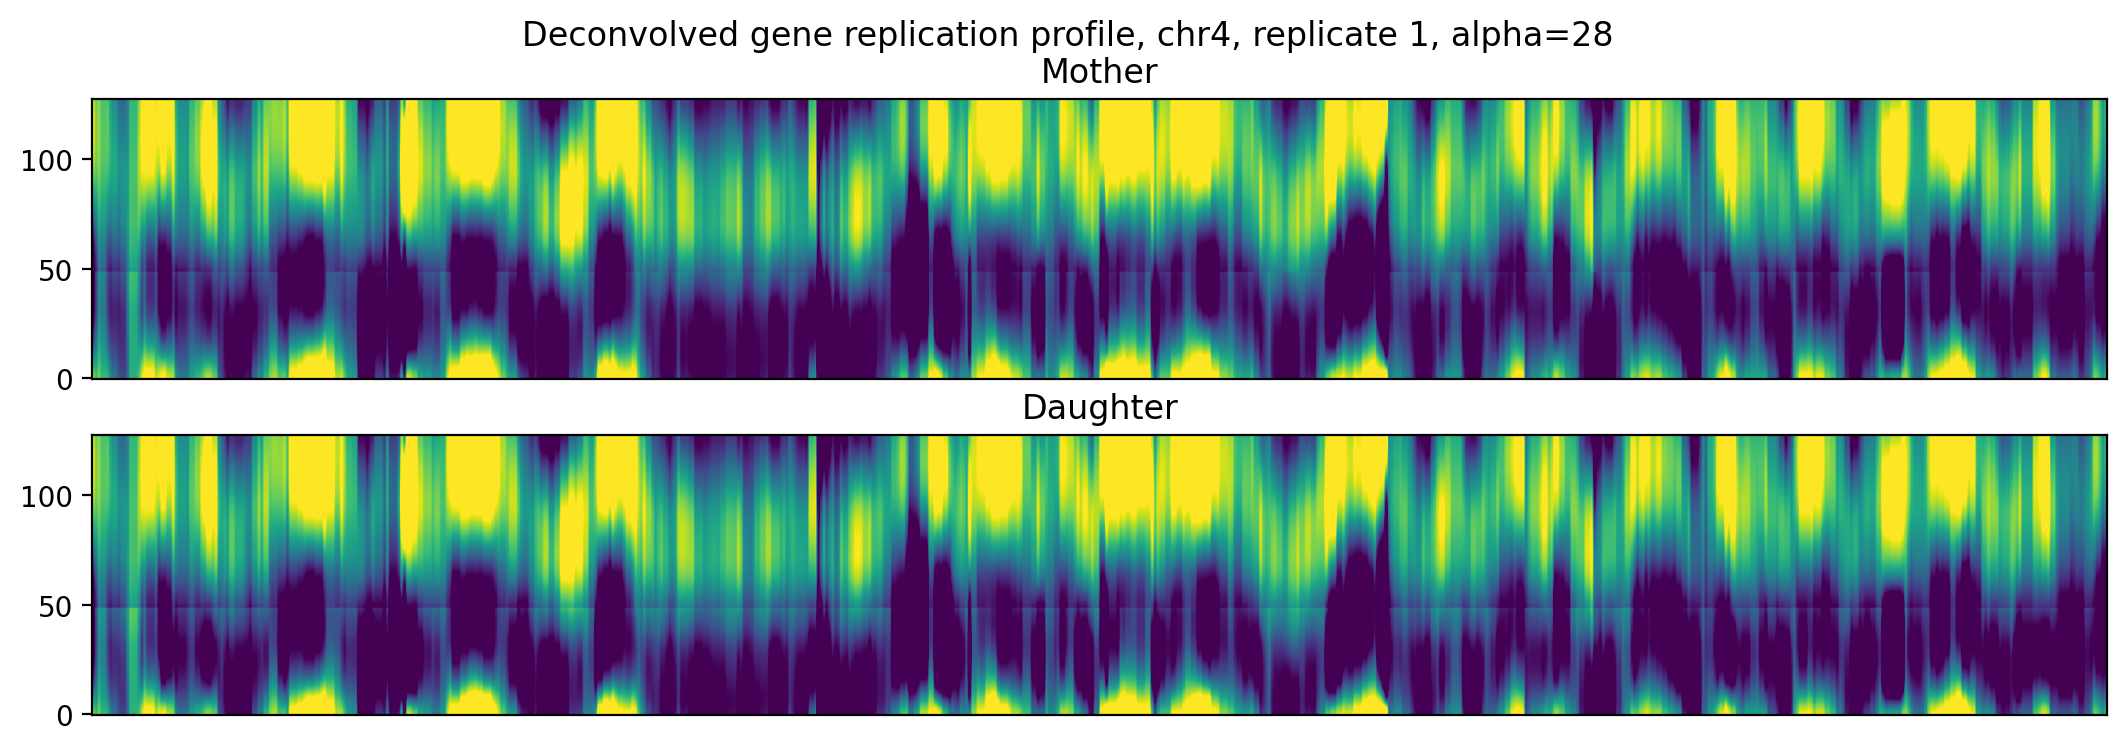

In [1031]:
plt.figure(figsize=(13, 4))

ind = -1
alpha = alphas[-1]

plt.subplot(2, 1, 1)
plt.imshow(alpha_fs[ind][t_indices], origin='lower', vmin=1, vmax=2, aspect='auto')
plt.title("Mother")
plt.xticks([])

plt.subplot(2, 1, 2)
plt.imshow(alpha_fs[ind][b_indices], origin='lower', vmin=1, vmax=2, aspect='auto')
plt.title("Daughter")
plt.xticks([])

plt.suptitle(f"Deconvolved gene replication profile, chr4, replicate 1, alpha={alpha}")
